# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [ ]:
#Mounts  google drive
from google.colab import drive
drive.mount('/content/drive')

#Import libraries
# Pandas and numpy to manipulate data
import pandas as pd
import numpy as np

# Matplotlib and seaborn
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

#To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

#To tune different models
from sklearn.model_selection import GridSearchCV

#To get different metric scores
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score,make_scorer



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Loading the dataset

In [ ]:
import pandas as pd
df_main = pd.read_csv('/content/drive/MyDrive/INNHotelsGroup.csv')
data = df_main.copy()

## Data Overview

- Observations
- Sanity checks

###View the first and last 5 rows of the data

In [ ]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68000,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50000,0,Canceled


In [ ]:
data.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80000,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95000,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39000,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50000,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67000,0,Not_Canceled


###Shape of the data

In [ ]:
data.shape

(36275, 19)

- There are 36275 rows and 19 columns

###Datatypes of the columns

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

- The following columns are objects: Booking ID, Type of meal plan, room type reserved, market segment type and booking status.Avg price per room is a float.
The rest of the columns are integers.

###Ckeck for missing values

In [ ]:
data.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


- There are no missing values

###Check for duplicate numbers

In [ ]:
data.duplicated().sum()

0

- There are no duplicates

In [ ]:
#Dropping unique data
data.drop(['Booking_ID'], axis=1, inplace=True)


###Statstical summary

In [ ]:
# Describe all data
data.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
no_of_adults,36275.00000,NaN,NaN,NaN,1.84496,0.51871,0.00000,2.00000,2.00000,2.00000,4.00000
no_of_children,36275.00000,NaN,NaN,NaN,0.10528,0.40265,0.00000,0.00000,0.00000,0.00000,10.00000
no_of_weekend_nights,36275.00000,NaN,NaN,NaN,0.81072,0.87064,0.00000,0.00000,1.00000,2.00000,7.00000
no_of_week_nights,36275.00000,NaN,NaN,NaN,2.20430,1.41090,0.00000,1.00000,2.00000,3.00000,17.00000
type_of_meal_plan,36275,4,Meal Plan 1,27835,NaN,NaN,NaN,NaN,NaN,NaN,NaN
required_car_parking_space,36275.00000,NaN,NaN,NaN,0.03099,0.17328,0.00000,0.00000,0.00000,0.00000,1.00000
room_type_reserved,36275,7,Room_Type 1,28130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_time,36275.00000,NaN,NaN,NaN,85.23256,85.93082,0.00000,17.00000,57.00000,126.00000,443.00000
arrival_year,36275.00000,NaN,NaN,NaN,2017.82043,0.38384,2017.00000,2018.00000,2018.00000,2018.00000,2018.00000
arrival_month,36275.00000,NaN,NaN,NaN,7.42365,3.06989,1.00000,5.00000,8.00000,10.00000,12.00000


- The average amount of adults booked was 1.84, range 0-4. The average amount of children booked were 0.11, range of 1-10.
- More weekend nights were booked with average of 2.2 nights (range 0-7), where only 0.81 weekend nights were booked on average (range of 0-17).
- Carpark booked was either booked(1) or not booked(0).
- The leadtime was an  average of 85.23 days and it ranged from 0-443 days.
- The arrival year is either in 2017 or 2018.
- Meal plan 1 is most frequently ordered.
- The average month of arrival is July and the average date is on the 15th of a month.
- The market segment is most frequently online.
- Repeated guest bookings and number of cancellations is on average is seldomly seen.
- The number of previous bookings not canceled is 0.15 on average wtih a range of 0-58.
- The average price per room is 100 Euros, with a range between 0- 540 Euros per night.
- There are a few special requests, which ranges between 0 and 5.
- The booking status is noted as canceled or not canceled.




# Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What are the busiest months in the hotel?
2. Which market segment do most of the guests come from?
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
4. What percentage of bookings are canceled?
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

##Create functions for histogram_boxplot, barplot, stacked barplot and distribution of target

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,  # Assign 'feature' to 'hue'
        palette="Paired",
        order=data[feature].value_counts().index[:n],
        legend=False,  # Disable the legend
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable

    """
    count = data[predictor].nunique()

    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=data[target].value_counts().index[-1], ascending=True
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=data[target].value_counts().index[-1], ascending=True
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#Adress important EDA questions

###1. Distribution of most busy months in the hotel

booking_status  Canceled  Not_Canceled    All
arrival_month                                
1                     24           990   1014
12                   402          2619   3021
2                    430          1274   1704
3                    700          1658   2358
11                   875          2105   2980
5                    948          1650   2598
4                    995          1741   2736
6                   1291          1912   3203
7                   1314          1606   2920
8                   1488          2325   3813
9                   1538          3073   4611
10                  1880          3437   5317
All                11885         24390  36275
------------------------------------------------------------------------------------------------------------------------


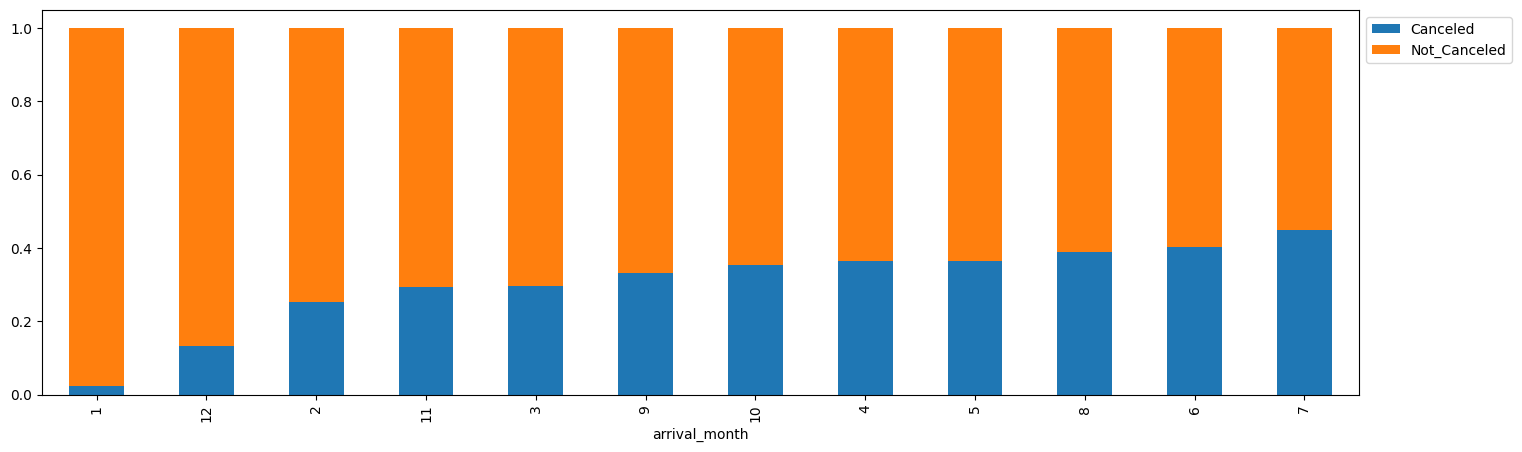

In [ ]:
#Stacked barplot of months with busiest bookings
stacked_barplot(data, 'arrival_month', 'booking_status')

- The top 5 busiest months in the hotel are November to March.
- These are the months when top revenue is most likely generated.
- In the Northern hemisphere this is during fall and winter. In the Southern hemisphere it would be spring and summer.

##2. Market segment distribution

booking_status       Canceled  Not_Canceled    All
market_segment_type                               
Complementary               0           391    391
Aviation                   37            88    125
Corporate                 220          1797   2017
Offline                  3153          7375  10528
Online                   8475         14739  23214
All                     11885         24390  36275
------------------------------------------------------------------------------------------------------------------------


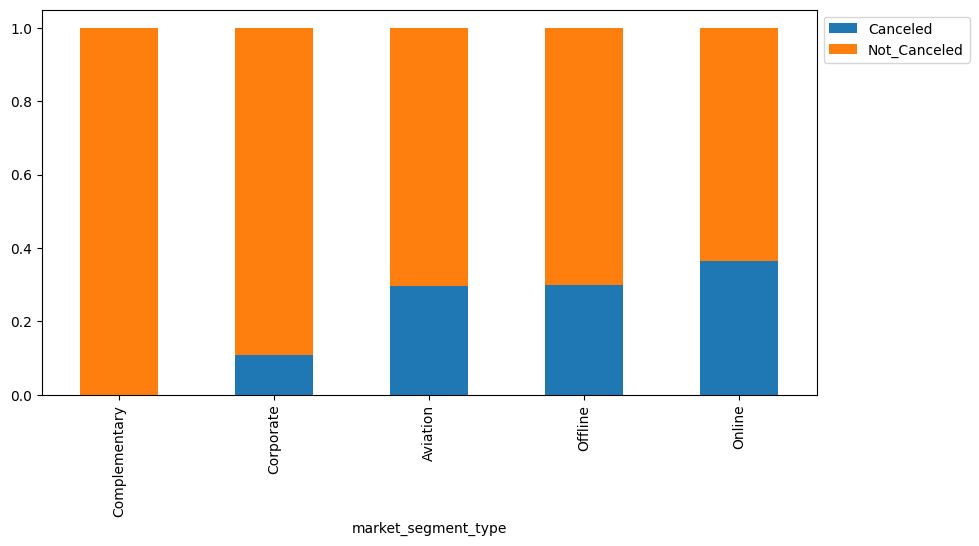

In [ ]:
#Stacked bar plot of the market segment distribution
stacked_barplot(data, 'market_segment_type', 'booking_status')


- Most of the guests come from the corporate market with the least cancelations
- The second most market segment is Aviation.
- More guests canceled when using online bookings versus offline.

##3. Distribution of room prices in the different market segments

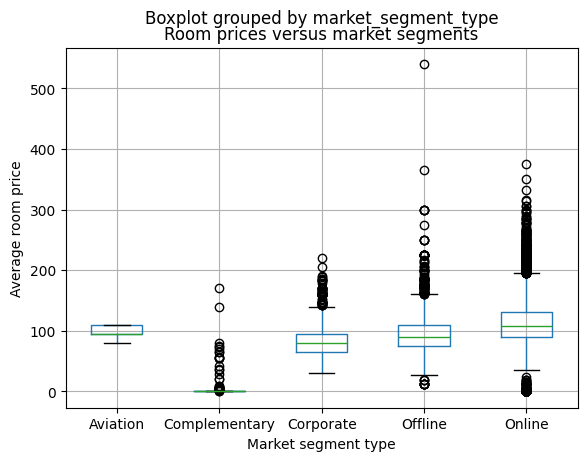

In [ ]:
#Room prices versus market segments
boxplot=data.boxplot(column='avg_price_per_room', by='market_segment_type')
plt.xlabel('Market segment type')
plt.ylabel('Average room price')
plt.title('Room prices versus market segments')
plt.show()



- The median for online, is about 120 Euros and is skewed to the right.
- The median for offline and corporate is about 80 Euros and is skewed to the right.
- The median for aviation is 100 Euros and it is normally distributed.
- Complementary has a median of zero and a lot of outliers to the right.

##4. Percentage of bookings canceled

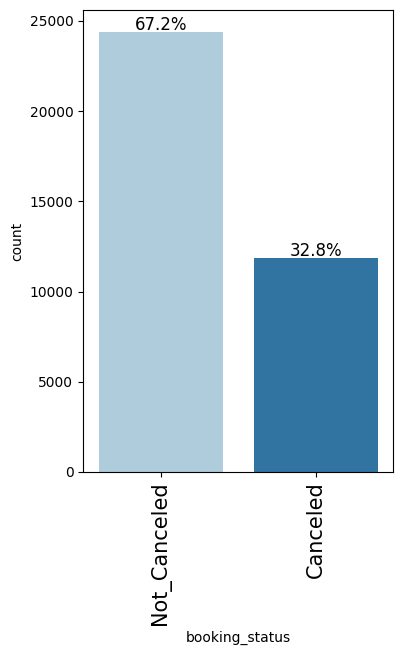

In [ ]:
#What percentage of the bookings were canceled
labeled_barplot(data, 'booking_status', perc=True)


- 32.8% of the bookings were canceled.

##5. Percentage of the repeating guests canceled

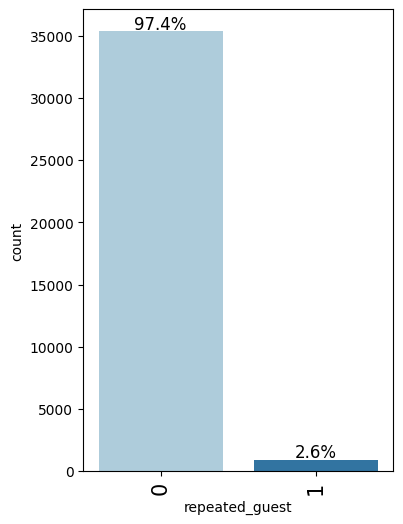

In [ ]:
#What percentage of repeating guests canceled
labeled_barplot(data, 'repeated_guest', perc=True)

- 2.6% of the repeated quests canceled

##6. Effect of special requests on cancelation

In [ ]:
#What percentage of guests with special requests canceled, calculate percentages for each special request using groupby
data.groupby(['no_of_special_requests'])['booking_status'].value_counts(normalize=True)
#Convert the proportions into percentages
data.groupby(['no_of_special_requests'])['booking_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'


no_of_special_requests  booking_status
0                       Not_Canceled       56.8%
                        Canceled           43.2%
1                       Not_Canceled       76.2%
                        Canceled           23.8%
2                       Not_Canceled       85.4%
                        Canceled           14.6%
3                       Not_Canceled      100.0%
4                       Not_Canceled      100.0%
5                       Not_Canceled      100.0%
Name: proportion, dtype: object

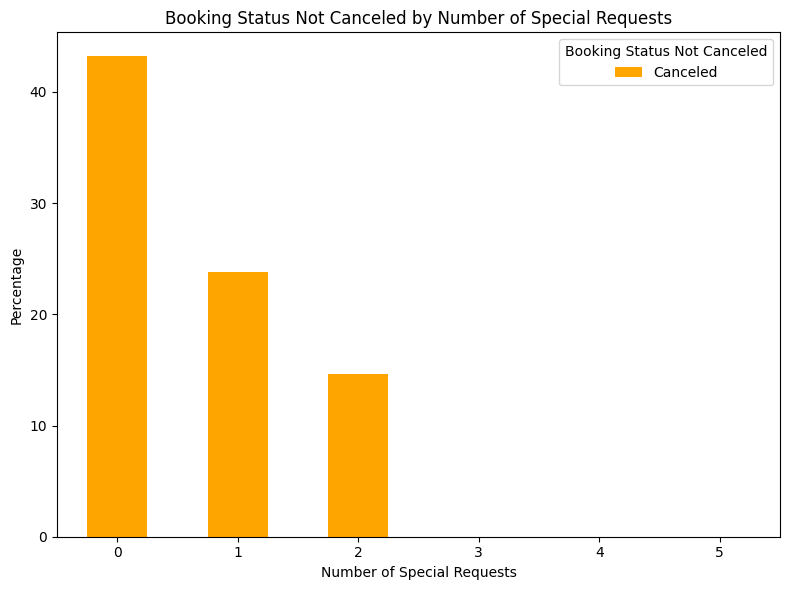

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data: Replace this with your actual dataset
data_requests = pd.DataFrame({
    'no_of_special_requests': [0, 1, 2, 3, 4, 5],
    'Canceled': [43.2, 23.8, 14.6, 0.0, 0.0, 0.0]
})

# Plot the stacked bar chart
data_requests.set_index('no_of_special_requests').plot(
    kind='bar',
    stacked=True,
    color=['orange', 'blue'],  # Colors: Orange for Not_Canceled, Blue for Canceled
    figsize=(8, 6)
)

# Add labels, title, and legend
plt.xlabel('Number of Special Requests')
plt.ylabel('Percentage')
plt.title('Booking Status Not Canceled by Number of Special Requests')
plt.legend(title='Booking Status Not Canceled')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.tight_layout()

# Show the plot
plt.show()


- 43.2% of guests with no requests,did not cancel.
- 23.8% of guests with 1 requests, did not cancel.
- 14.6% of guests with 2 requests, did not cancel.


##Univariate analysis

###Distribution number of adults


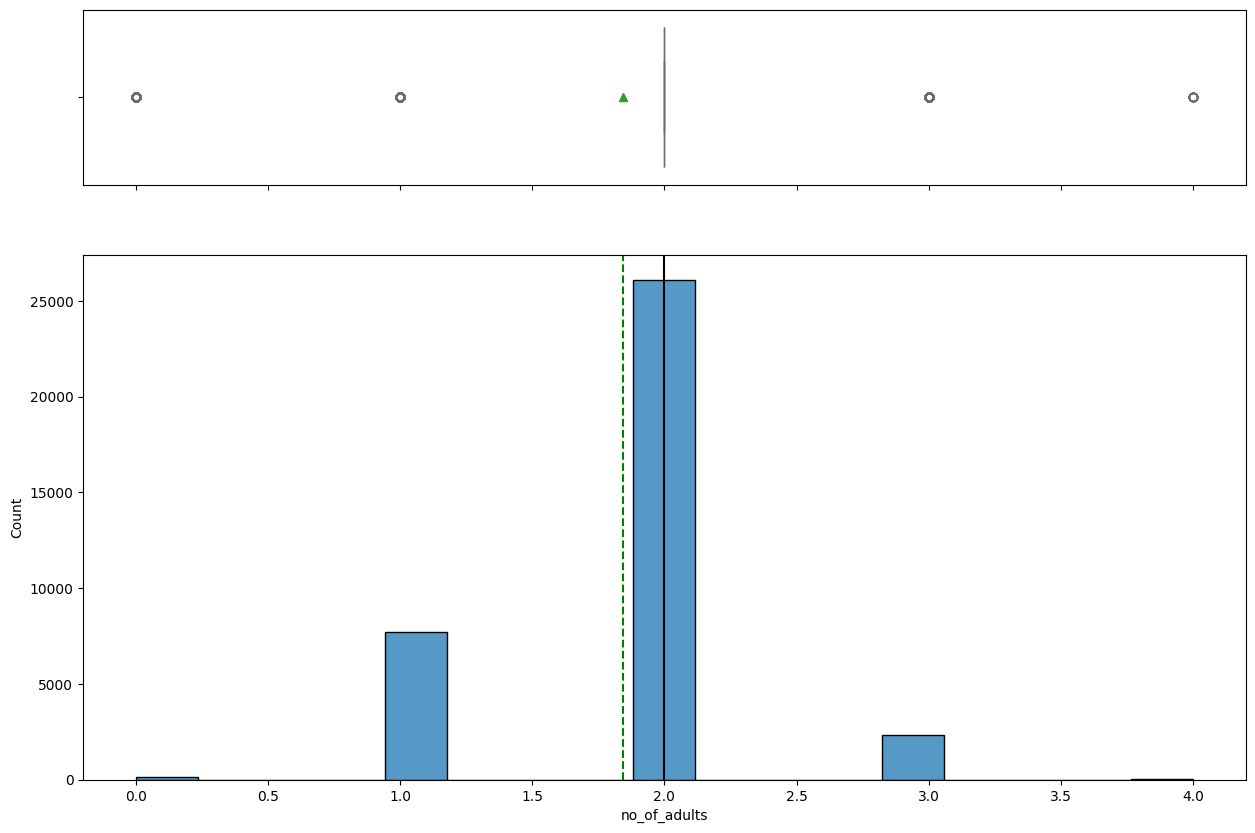

In [ ]:

histogram_boxplot(data,'no_of_adults')

- The mean number of adults is just under 2.
- Data has outliers.

###Distribution of number of weekend nights

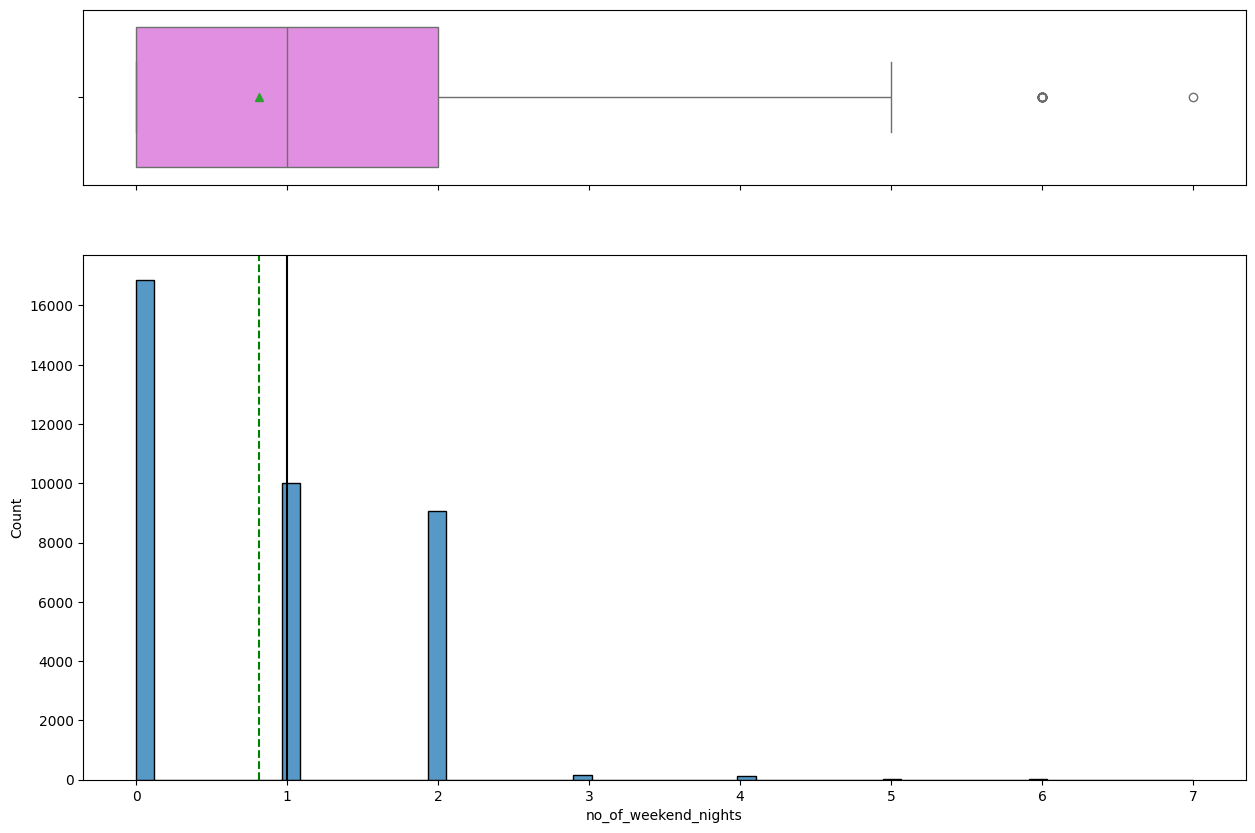

In [ ]:
histogram_boxplot(data,'no_of_weekend_nights')

- The mean weekend nights are about 0.8.
- The graph is skewed to the right.

###Distribution of number of week nights

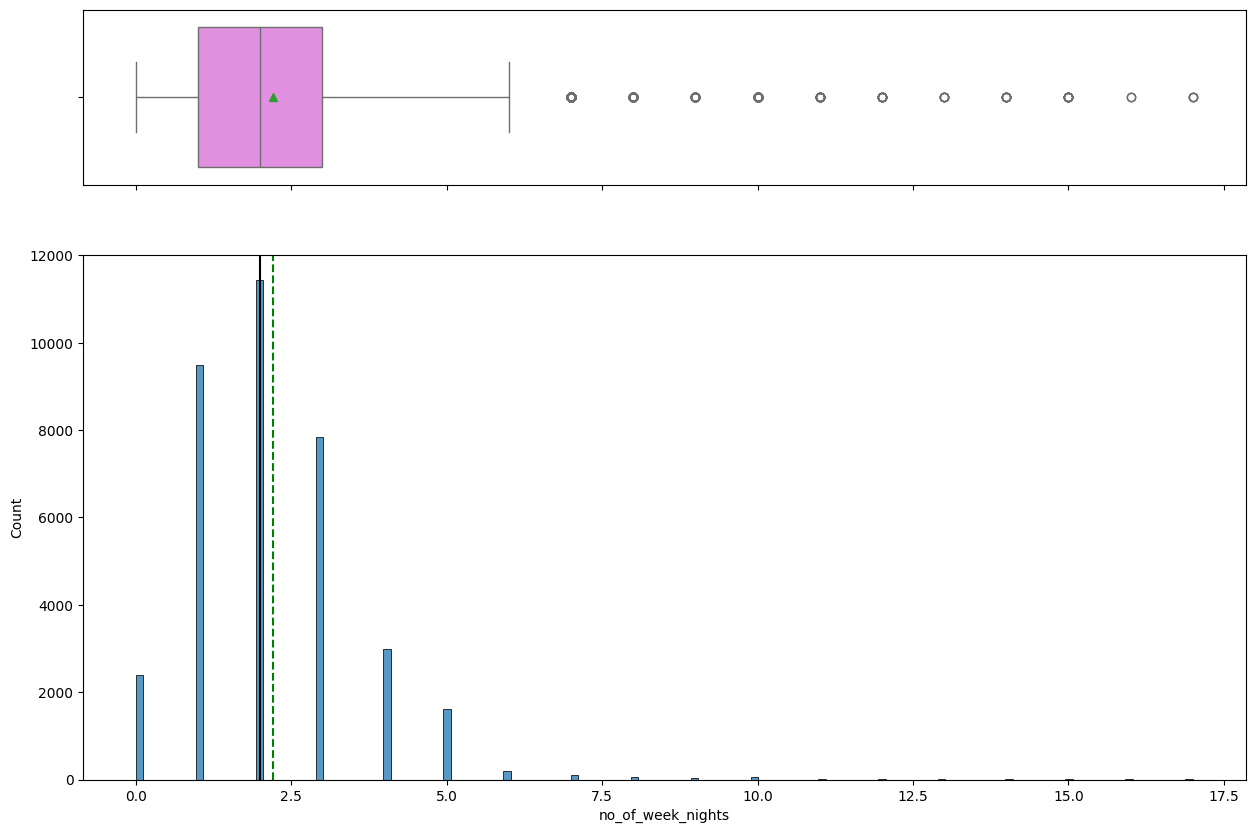

In [ ]:
histogram_boxplot(data,'no_of_week_nights')

- The mean is about 2.4 nights.
- Outliers are present to the right.


###Type of meal plan

In [ ]:
labeled_barplot(data,'type_of_meal_plan',perc=True)

- The most frequent meal plan selected is meal plan 1 which is breakfast.

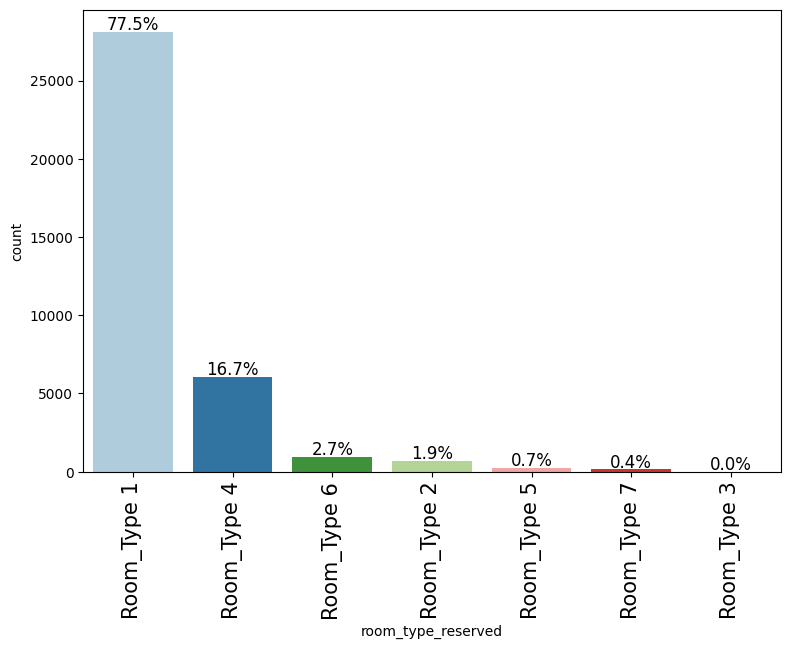

In [ ]:
labeled_barplot(data,'room_type_reserved',perc=True)

- Room type 1 is the most frequent room type booked.

###Percentage of guests requiring a car parking space

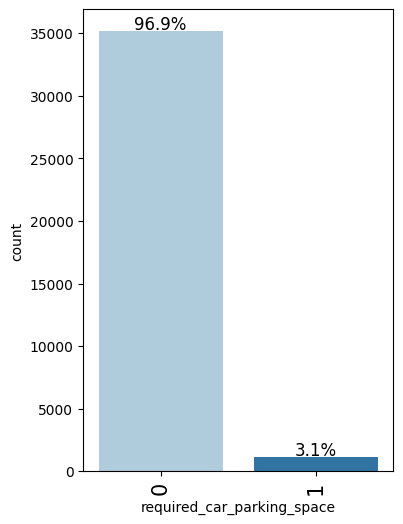

In [ ]:
labeled_barplot(data,'required_car_parking_space',perc=True)

- Only 3.1% of customers required a parking space

###Distribution of Lead time

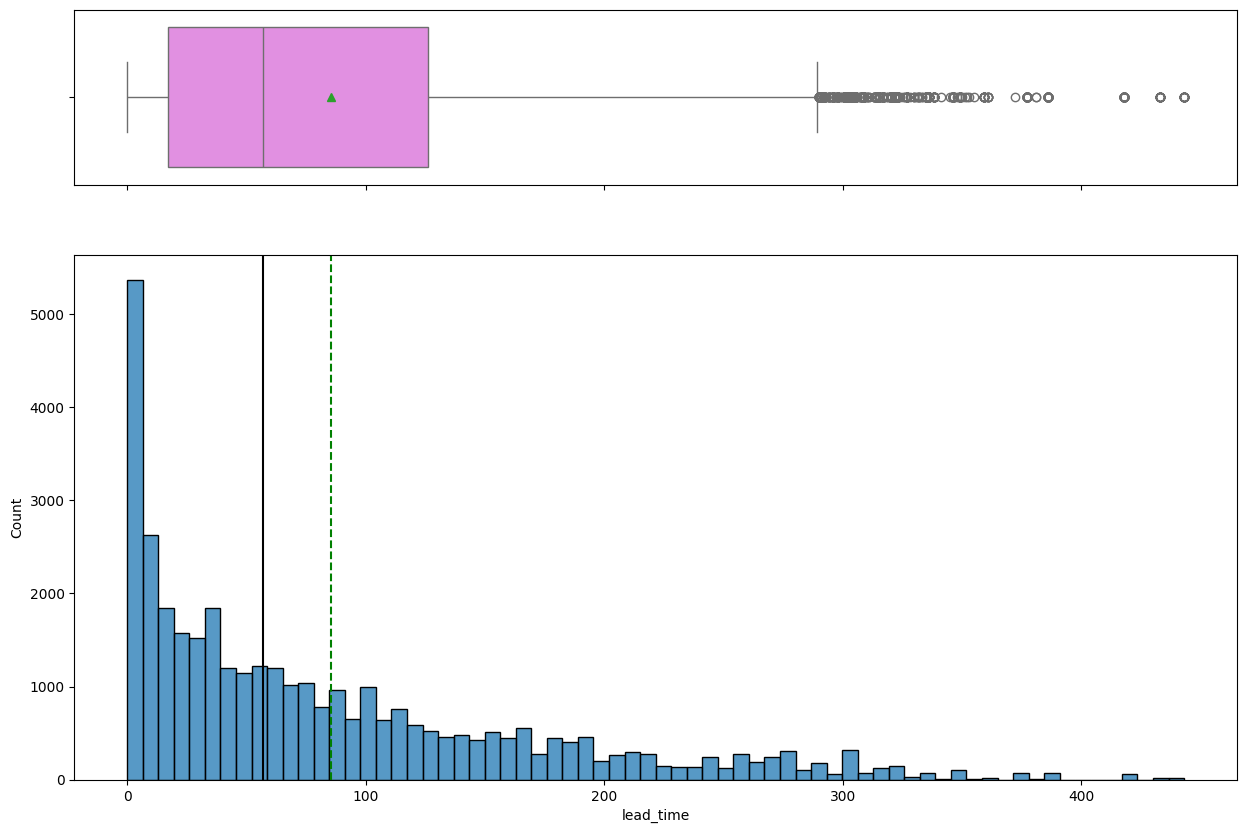

In [ ]:
histogram_boxplot(data,'lead_time')

- The mean lead time is approximately 80 days.
- The data is extremely right skewed.

###Percentage of arrival per year

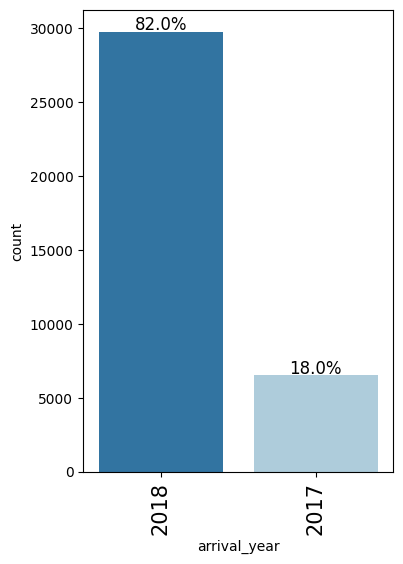

In [ ]:
labeled_barplot(data,'arrival_year',perc=True)

-82% of the data was obtained in 2018, and 18% was obtained in 2017.

###Percentage arrival per month

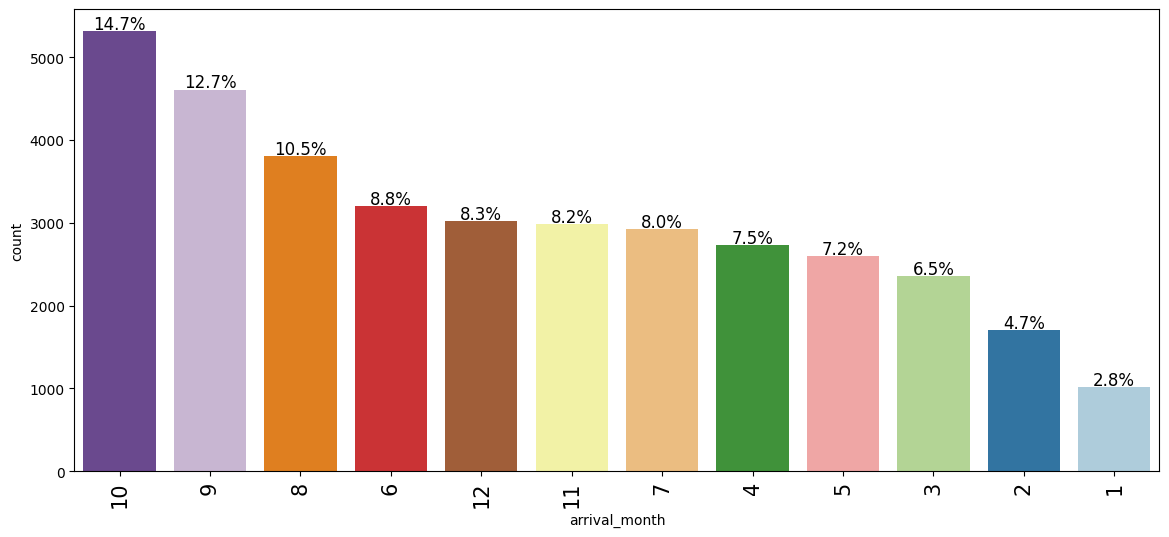

In [ ]:
labeled_barplot(data,'arrival_month',perc=True)

- The top 5 months were June, August-October(maximum arrivals in October) and December.
- The bottom 5 months were, January (least arrivals in January) to May.

###Percentage arrival per date of the month

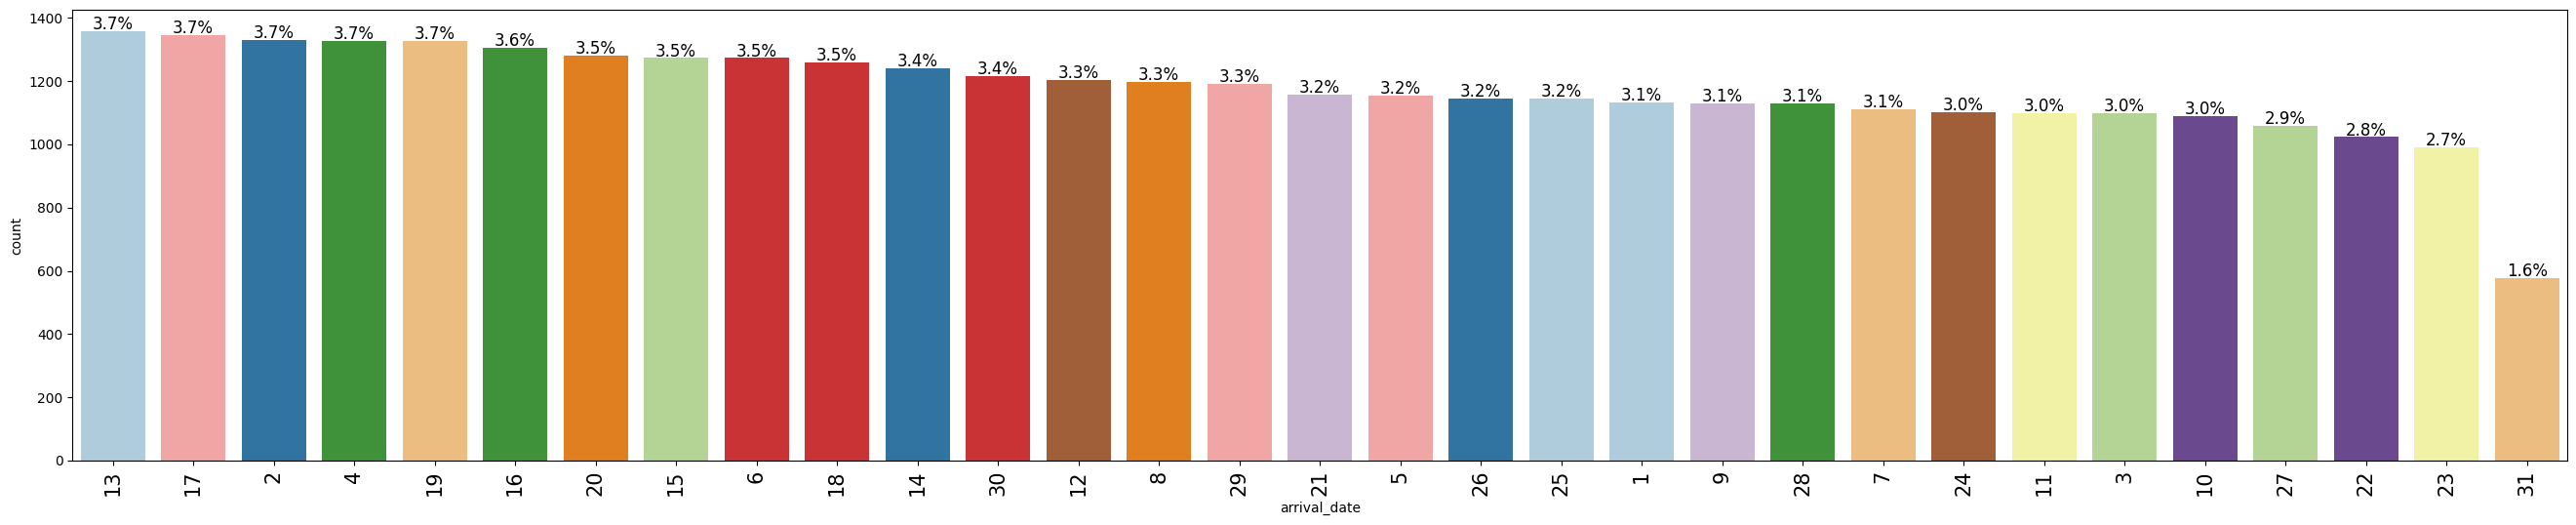

In [ ]:
labeled_barplot(data,'arrival_date',perc=True)


- There are no specific dates of the month correlating with arrivals.

###Distribution of repeated guests

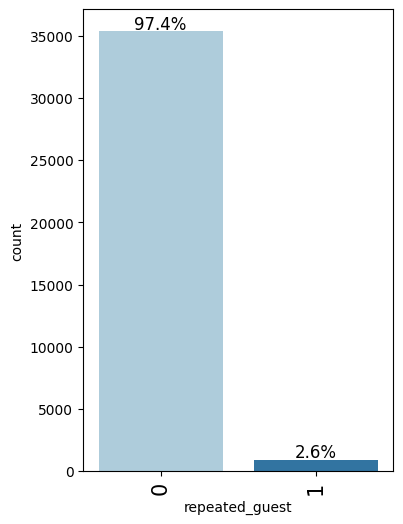

In [ ]:
labeled_barplot(data,'repeated_guest',perc=True)


- Only 2.6% of the bookings were repeated guests.

###Distribution of number of previous cancellations

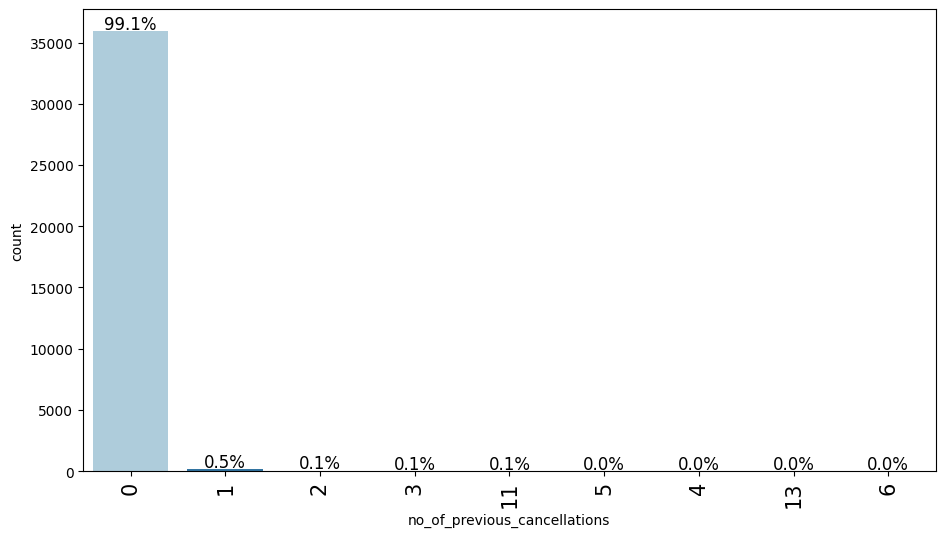

In [ ]:
labeled_barplot(data,'no_of_previous_cancellations',perc=True)

- Only 0.9% of the bookings were corellated with previous cancellations.

###Distribution of number of previous bookings not canceled

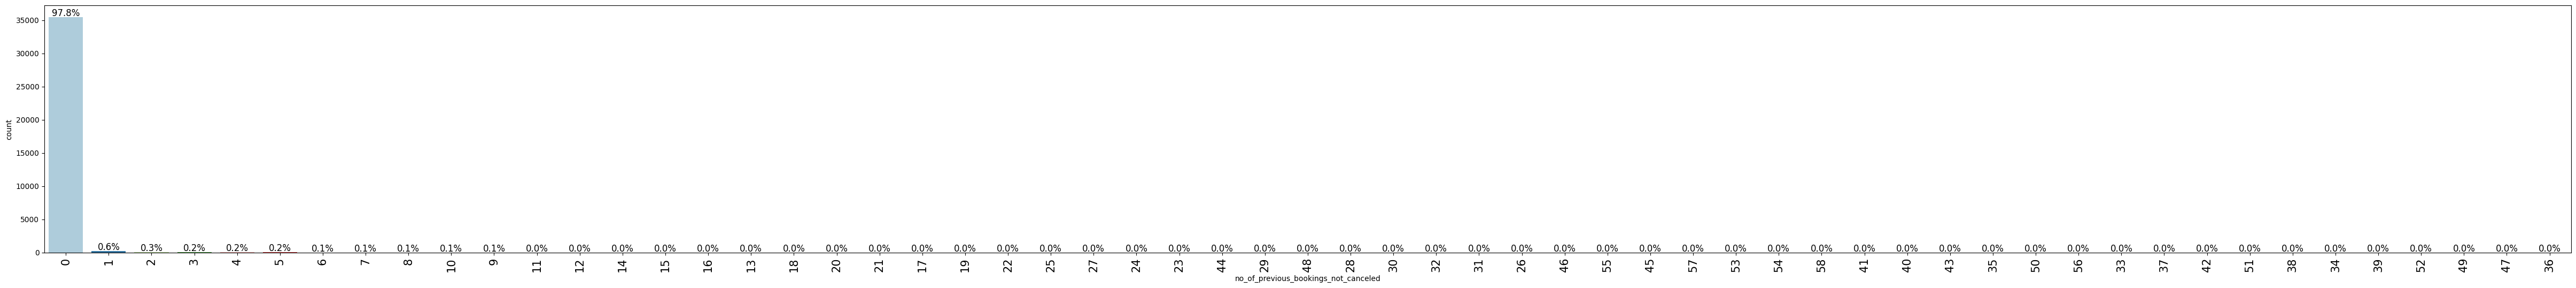

In [ ]:
labeled_barplot(data,'no_of_previous_bookings_not_canceled',perc=True)

97.8% of previous bookings bookings were not canceled.

###Distribution of the average price per room

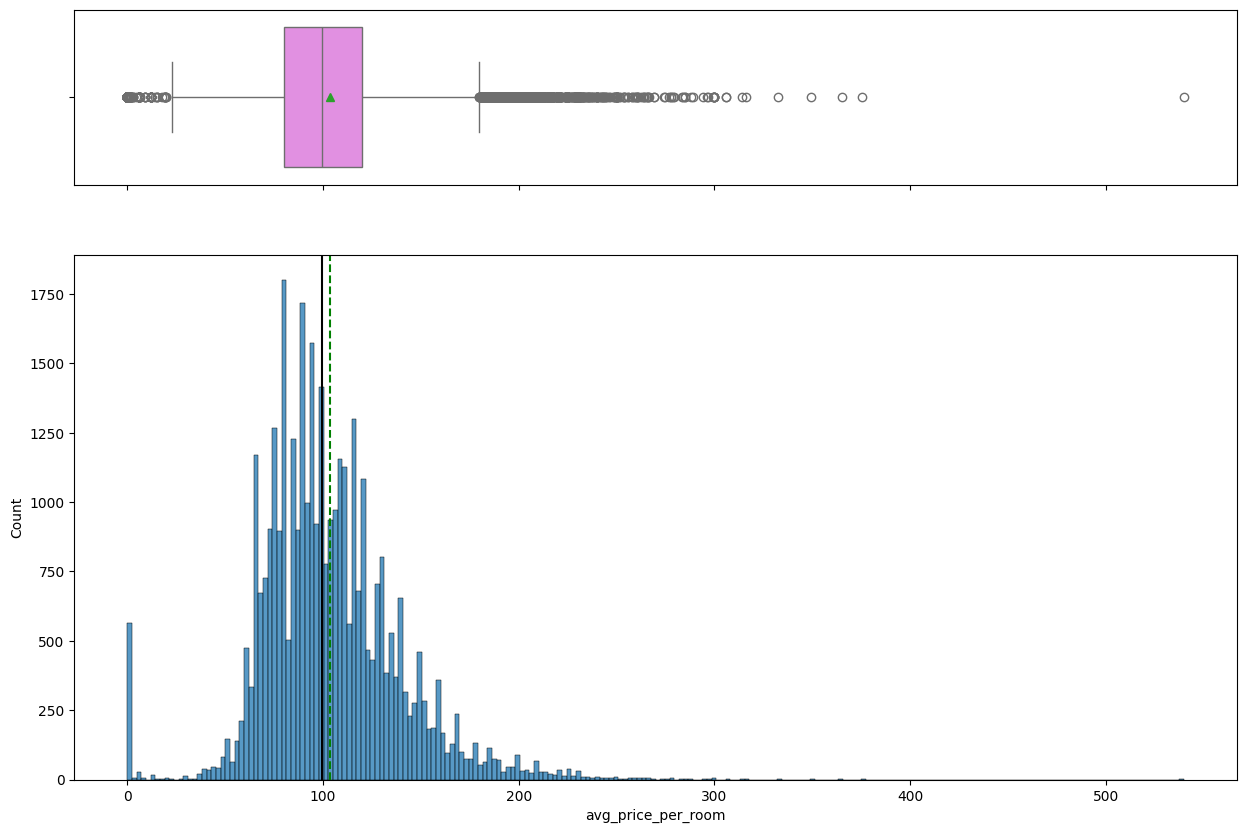

In [ ]:
histogram_boxplot(data,'avg_price_per_room')

- Approximately 110 Euros is the mean price for a room.
- The data is slightly skewed to the right.
- Outliers are present.

#Bivariate analysis

##Heatmap of numeric variables

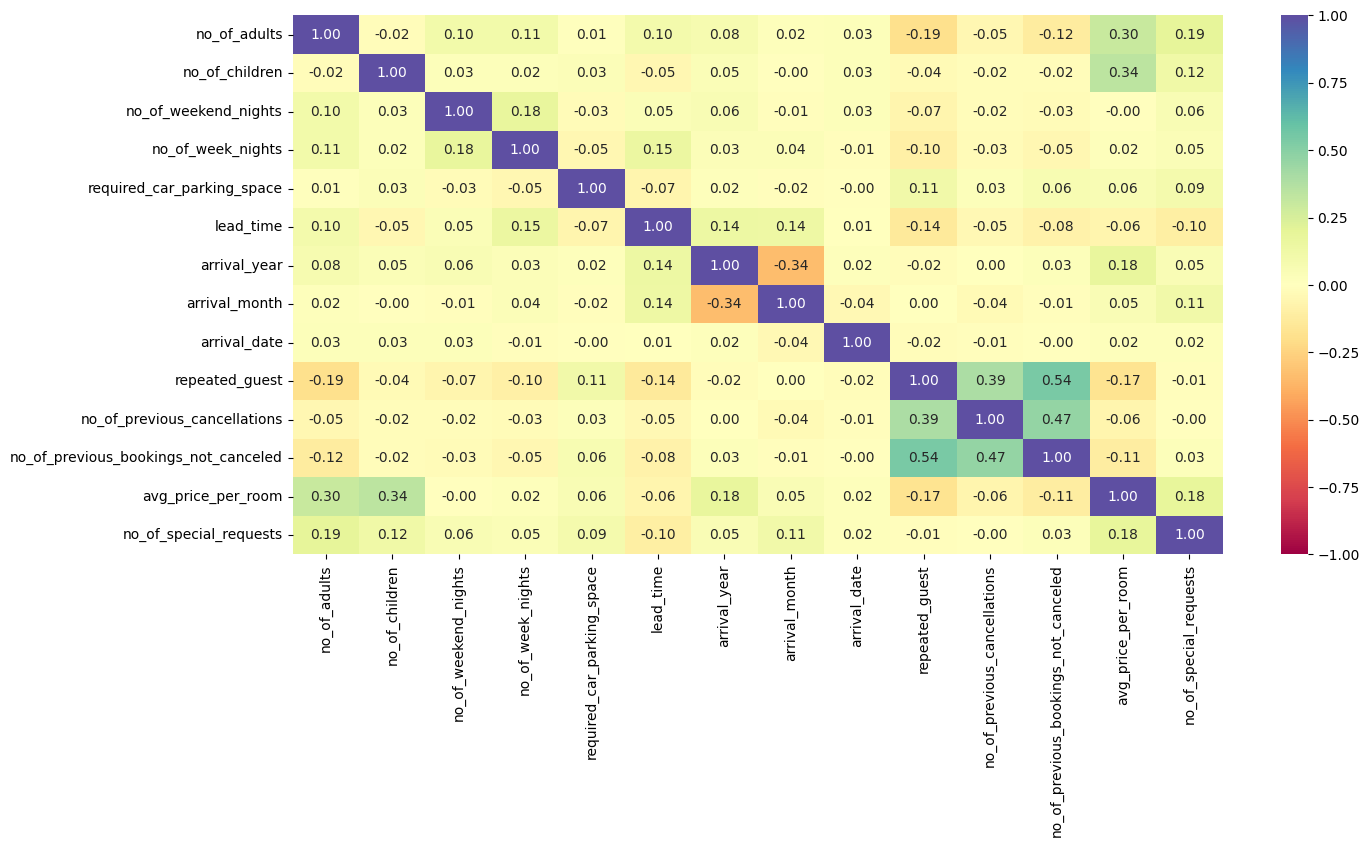

In [ ]:
# Filter the DataFrame to include only numerical columns
numerical_df = data.select_dtypes(include=['number'])

# Plot the heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(numerical_df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**No significant strong corellations are observed**

**Positive correlation:**
- There is a weak positive correlation between canceled bookings and lead time.
- There is a weak positive correlation between canceled bookings and average price per room.
- There is a weak positive correlation between canceled bookings and arrival year.

**Negative correlation:**
- There is a negative correlation between canceled bookings and number of special requests.
- There is a weak negative correlation between canceled bookings and repeated guest.


##Booking status versus lead time

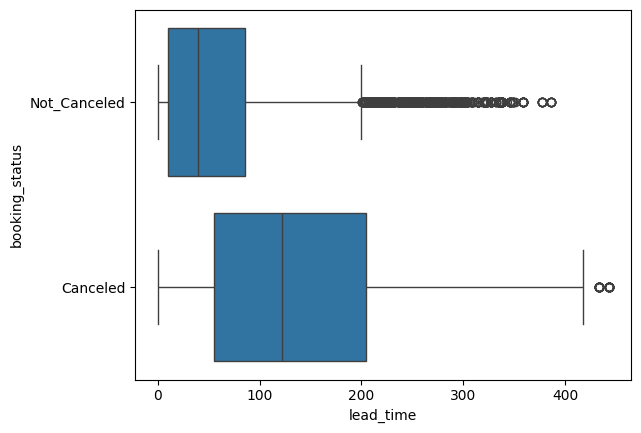

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=data, x='lead_time', y='booking_status')
plt.show()

- The mean lead time for canceled bookings is about 130 days, with a range between 0 and 420. The data is right skewed.
- The mean lead time for not canceled bookings is about 50 days, with a range between 0 and 200 days. The data is right skewed with many outliers to the right.

###Booking status vs price

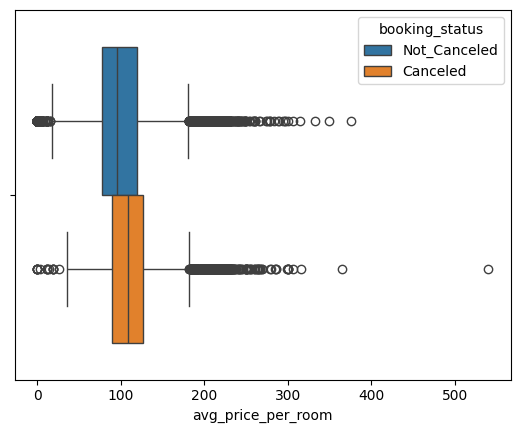

In [ ]:
sns.boxplot(data=data, x='avg_price_per_room', hue='booking_status')
figsize=(20,14)
plt.show()

- The mean price per room for a canceled booking is about 110 Euros.
- The mean price per room for a not canceled booking is lower atabout 80 Euros.
- The range between canceled and not canceled is the same with a maximum of 200 Euros.

#Pre-processing

##Create dummy variables

In [ ]:
import pandas as pd

def create_dummy_variables(df, drop_first=True):
    """
    Create dummy variables for all categorical columns in a dataframe.

    Parameters:
    df_main (pd.DataFrame): Input DataFrame
    drop_first (bool): Whether to drop the first category for each variable to avoid multicollinearity

    Returns:
    pd.DataFrame: DataFrame with dummy variables
    """
    # Make a copy of the original dataframe
    data = df_main.copy()

    # Get list of categorical columns
    categorical_columns = data.select_dtypes(include=['object', 'category']).columns

    # Print information about the conversion
    print(f"Converting {len(categorical_columns)} categorical columns to dummy variables:")
    for col in categorical_columns:
        unique_values = data[col].nunique()
        print(f"- {col}: {unique_values} unique values")

    # Create dummy variables
    dummies = pd.get_dummies(data, columns=categorical_columns, drop_first=drop_first)

    # Convert all dummy variables to float
    dummy_columns = [col for col in dummies.columns if col not in df.select_dtypes(exclude=['object', 'category']).columns]
    dummies[dummy_columns] = dummies[dummy_columns].astype(float)

    # Print shape information
    print(f"\nOriginal shape: {df.shape}")
    print(f"New shape: {dummies.shape}")

    return dummies

# Example usage:
# encoded_df = create_dummy_variables(your_dataframe)

In [ ]:
import pandas as pd

# Create dummy variables
dummies = pd.get_dummies(data, drop_first=True)
dummies = dummies.astype(float)

# Display info about the result
print("\nOriginal shape:", data.shape)
print("Shape after creating dummies:", dummies.shape)

# Display first few rows to verify the conversion
print("\nFirst few rows of dummy variables:")
print(dummies.head())

# Show column names
print("\nNew columns created:")
print(dummies.columns.tolist())


Original shape: (36275, 18)
Shape after creating dummies: (36275, 28)

First few rows of dummy variables:
   no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
0       2.00000         0.00000               1.00000            2.00000   
1       2.00000         0.00000               2.00000            3.00000   
2       1.00000         0.00000               2.00000            1.00000   
3       2.00000         0.00000               0.00000            2.00000   
4       2.00000         0.00000               1.00000            1.00000   

   required_car_parking_space  lead_time  arrival_year  arrival_month  \
0                     0.00000  224.00000    2017.00000       10.00000   
1                     0.00000    5.00000    2018.00000       11.00000   
2                     0.00000    1.00000    2018.00000        2.00000   
3                     0.00000  211.00000    2018.00000        5.00000   
4                     0.00000   48.00000    2018.00000        4.00000  

In [ ]:
# Check unique values in each categorical column
categorical_columns = data.select_dtypes(include=['object', 'category']).columns
print("Number of unique values in each categorical column:")
for col in categorical_columns:
    n_unique = data[col].nunique()
    print(f"{col}: {n_unique} unique values")

Number of unique values in each categorical column:
type_of_meal_plan: 4 unique values
room_type_reserved: 7 unique values
market_segment_type: 5 unique values
booking_status: 2 unique values


In [ ]:
# First let's see the original data
print("Original data head:")
print(data.head())

# Now create and store the dummy variables back to data
data = pd.get_dummies(data, drop_first=True)
data = data.astype(float)

print("\nData after dummy encoding:")
print(data.head())

Original data head:
   no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
0             2               0                     1                  2   
1             2               0                     2                  3   
2             1               0                     2                  1   
3             2               0                     0                  2   
4             2               0                     1                  1   

  type_of_meal_plan  required_car_parking_space room_type_reserved  lead_time  \
0       Meal Plan 1                           0        Room_Type 1        224   
1      Not Selected                           0        Room_Type 1          5   
2       Meal Plan 1                           0        Room_Type 1          1   
3       Meal Plan 1                           0        Room_Type 1        211   
4      Not Selected                           0        Room_Type 1         48   

   arrival_year  arrival_month  arri

In [ ]:
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,booking_status_Not_Canceled
0,2.00000,0.00000,1.00000,2.00000,0.00000,224.00000,2017.00000,10.00000,2.00000,0.00000,0.00000,0.00000,65.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,1.00000
1,2.00000,0.00000,2.00000,3.00000,0.00000,5.00000,2018.00000,11.00000,6.00000,0.00000,0.00000,0.00000,106.68000,1.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,1.00000
2,1.00000,0.00000,2.00000,1.00000,0.00000,1.00000,2018.00000,2.00000,28.00000,0.00000,0.00000,0.00000,60.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000
3,2.00000,0.00000,0.00000,2.00000,0.00000,211.00000,2018.00000,5.00000,20.00000,0.00000,0.00000,0.00000,100.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000
4,2.00000,0.00000,1.00000,1.00000,0.00000,48.00000,2018.00000,4.00000,11.00000,0.00000,0.00000,0.00000,94.50000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000


In [ ]:
# Print all column names
print("All columns:")
print(dummies.columns.tolist())

# Check if 'booking_ID' exists in any form
possible_id_columns = [col for col in dummies.columns if 'booking' in col.lower() or 'id' in col.lower()]
print("\nPossible ID-like columns:", possible_id_columns)

In [ ]:
# Check if 'no_of_previous_bookings_not_canceled' is the unique identifier column
print("Unique values in 'no_of_previous_bookings_not_canceled':")
print(dummies['no_of_previous_bookings_not_canceled'].value_counts())

# If it appears to be a unique identifier, drop it
data = dummies.drop('no_of_previous_bookings_not_canceled', axis=1)

# Verify the result
print("\nNew dataframe shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Unique values in 'no_of_previous_bookings_not_canceled':
no_of_previous_bookings_not_canceled
0.00000     35463
1.00000       228
2.00000       112
3.00000        80
4.00000        65
5.00000        60
6.00000        36
7.00000        24
8.00000        23
10.00000       19
9.00000        19
11.00000       15
12.00000       12
14.00000        9
15.00000        8
16.00000        7
13.00000        7
18.00000        6
20.00000        6
21.00000        6
17.00000        6
19.00000        6
22.00000        6
25.00000        3
27.00000        3
24.00000        3
23.00000        3
44.00000        2
29.00000        2
48.00000        2
28.00000        2
30.00000        2
32.00000        2
31.00000        2
26.00000        2
46.00000        1
55.00000        1
45.00000        1
57.00000        1
53.00000        1
54.00000        1
58.00000        1
41.00000        1
40.00000        1
43.00000        1
35.00000        1
50.00000        1
56.00000        1
33.00000        1
37.00000        1
42.000

# EDA review

#Adress important EDA questions

##2. Market segment distribution

booking_status_Not_Canceled    0.00000  1.00000    All
market_segment_type_Corporate                         
1.00000                            220     1797   2017
0.00000                          11665    22593  34258
 All                             11885    24390  36275
------------------------------------------------------------------------------------------------------------------------


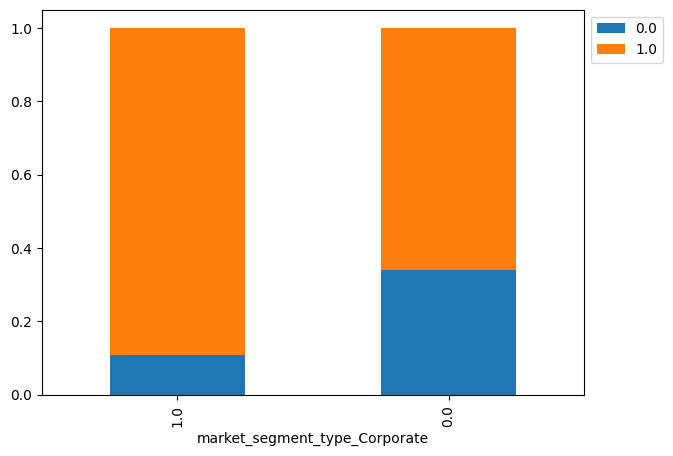

In [ ]:
#Stacked bar plot of the market segment distribution
stacked_barplot(data, 'market_segment_type_Corporate', 'booking_status_Not_Canceled')


- EDA for corporate market segment type similar to the previous one.

##3. Distribution of room prices in the different market segments

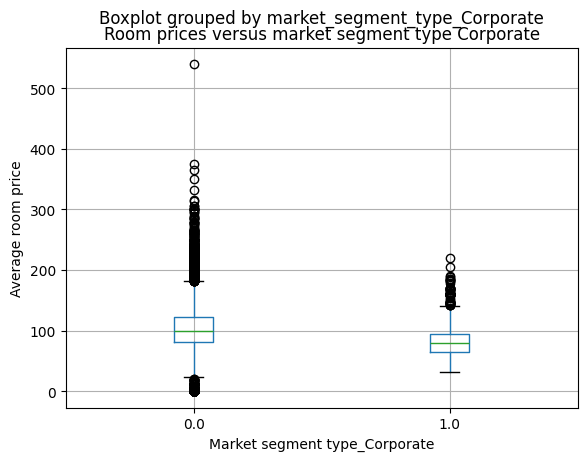

In [ ]:
#Room prices versus market segments
boxplot=data.boxplot(column='avg_price_per_room', by='market_segment_type_Corporate')
plt.xlabel('Market segment type_Corporate')
plt.ylabel('Average room price')
plt.title('Room prices versus market segment type Corporate')
plt.show()



- The Corporate market segment's mean and distribution is the same as previous EDA.

##4. Percentage of bookings canceled

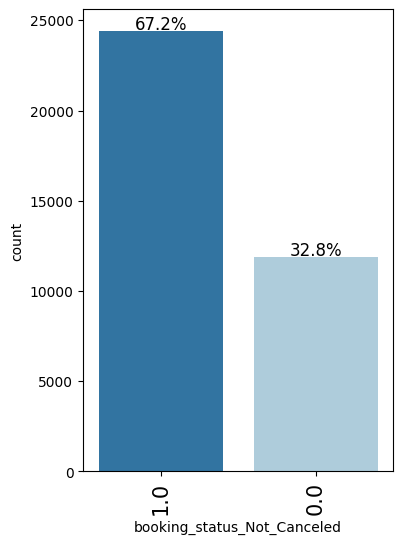

In [ ]:
#What percentage of the bookings were canceled
labeled_barplot(data, 'booking_status_Not_Canceled', perc=True)


- 32.8% of the bookings were canceled.

##5. Percentage of the repeating guests canceled

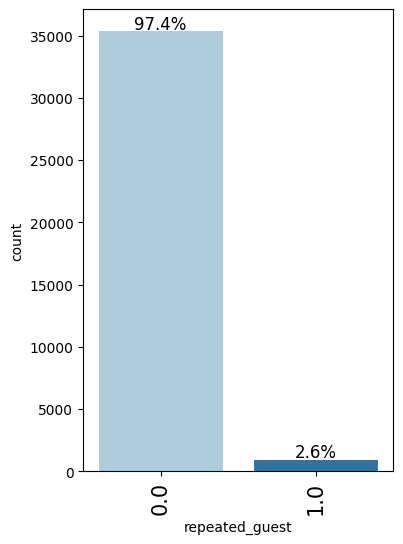

In [ ]:
#What percentage of repeating guests canceled
labeled_barplot(data, 'repeated_guest', perc=True)

- 2.6% of the repeated quests canceled

##6. Effect of special requests on cancelation

In [ ]:
#What percentage of guests with special requests canceled, calculate percentages for each special request using groupby
data.groupby(['no_of_special_requests'])['booking_status_Not_Canceled'].value_counts(normalize=True)
#Convert the proportions into percentages
data.groupby(['no_of_special_requests'])['booking_status_Not_Canceled'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'


no_of_special_requests  booking_status_Not_Canceled
0.00000                 1.00000                         56.8%
                        0.00000                         43.2%
1.00000                 1.00000                         76.2%
                        0.00000                         23.8%
2.00000                 1.00000                         85.4%
                        0.00000                         14.6%
3.00000                 1.00000                        100.0%
4.00000                 1.00000                        100.0%
5.00000                 1.00000                        100.0%
Name: proportion, dtype: object

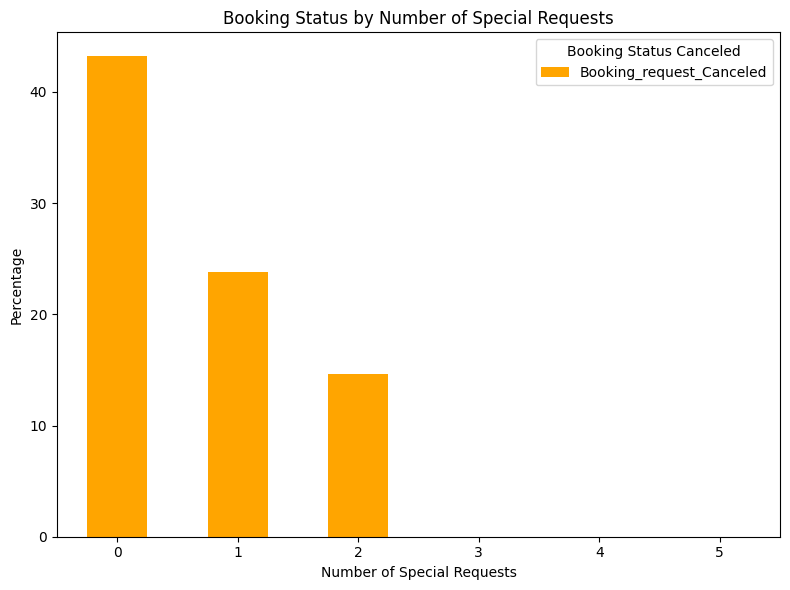

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Data: Replace this with your actual dataset
data_requests = pd.DataFrame({
    'no_of_special_requests': [0, 1, 2, 3, 4, 5],
    'Booking_request_Canceled': [43.2, 23.8, 14.6, 0.0, 0.0, 0.0]
})

# Plot the stacked bar chart
data_requests.set_index('no_of_special_requests').plot(
    kind='bar',
    stacked=True,
    color=['orange', 'blue'],  # Colors: Orange for Canceled, Blue for Not Canceled
    figsize=(8, 6)
)

# Add labels, title, and legend
plt.xlabel('Number of Special Requests')
plt.ylabel('Percentage')
plt.title('Booking Status by Number of Special Requests')
plt.legend(title='Booking Status Canceled')
plt.xticks(rotation=0)  # Keep x-axis labels horizontal
plt.tight_layout()

# Show the plot
plt.show()


-Graph similar to previous

## Let's look at the distribution of target variable


In [ ]:
data['booking_status_Not_Canceled'].value_counts()


,count
booking_status_Not_Canceled,
1.00000,24390
0.00000,11885


- The number of bookings canceled were 11885.
- 32.8% of the bookings were canceled.

## Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

- We observe that there is multicollinearity present in the data.



In [ ]:
# VIF only for existing columns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add constant for intercept
X = add_constant(data)

# Recalculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


                              feature            VIF
0                               const 39458807.00866
1                        no_of_adults        1.33894
2                      no_of_children        1.99818
3                no_of_weekend_nights        1.07011
4                   no_of_week_nights        1.09748
5          required_car_parking_space        1.04085
6                           lead_time        1.71933
7                        arrival_year        1.42746
8                       arrival_month        1.27459
9                        arrival_date        1.00658
10                     repeated_guest        1.54459
11       no_of_previous_cancellations        1.19437
12                 avg_price_per_room        2.08678
13             no_of_special_requests        1.41303
14      type_of_meal_plan_Meal Plan 2        1.26295
15      type_of_meal_plan_Meal Plan 3        1.01799
16     type_of_meal_plan_Not Selected        1.27581
17     room_type_reserved_Room_Type 2        1

In [ ]:
X= data.drop(['market_segment_type_Corporate','market_segment_type_Offline','market_segment_type_Online'], axis=1)
X= add_constant(X)

# Recalculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                              feature            VIF
0                               const 39275573.75001
1                        no_of_adults        1.28378
2                      no_of_children        1.99259
3                no_of_weekend_nights        1.06150
4                   no_of_week_nights        1.09152
5          required_car_parking_space        1.03497
6                           lead_time        1.61521
7                        arrival_year        1.42116
8                       arrival_month        1.27269
9                        arrival_date        1.00610
10                     repeated_guest        1.32882
11       no_of_previous_cancellations        1.18604
12                 avg_price_per_room        2.02039
13             no_of_special_requests        1.24082
14      type_of_meal_plan_Meal Plan 2        1.20272
15      type_of_meal_plan_Meal Plan 3        1.01797
16     type_of_meal_plan_Not Selected        1.16411
17     room_type_reserved_Room_Type 2        1

In [ ]:
X = data.drop(['room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3',
                'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5',
                'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7','market_segment_type_Corporate','market_segment_type_Offline','market_segment_type_Online',
                ],
               axis=1)
X = add_constant(X)

# Recalculate VIF
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                              feature            VIF
0                               const 38904625.37014
1                        no_of_adults        1.21501
2                      no_of_children        1.18962
3                no_of_weekend_nights        1.05998
4                   no_of_week_nights        1.08284
5          required_car_parking_space        1.03426
6                           lead_time        1.59333
7                        arrival_year        1.40775
8                       arrival_month        1.27069
9                        arrival_date        1.00534
10                     repeated_guest        1.32287
11       no_of_previous_cancellations        1.18544
12                 avg_price_per_room        1.73134
13             no_of_special_requests        1.22706
14      type_of_meal_plan_Meal Plan 2        1.18493
15      type_of_meal_plan_Meal Plan 3        1.00859
16     type_of_meal_plan_Not Selected        1.11088
17  market_segment_type_Complementary        1

### Splitting data into train and test


In [ ]:
X =data.drop('booking_status_Not_Canceled',axis=1)
y =data['booking_status_Not_Canceled']
import statsmodels.api as sm
#Add constant to X variable
X= sm.add_constant(X)

# Splitting data in train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.30, random_state=1,
)

In [ ]:
X_train.var()


,0
const,0.00000
no_of_adults,0.27008
no_of_children,0.16632
no_of_weekend_nights,0.76274
no_of_week_nights,1.98903
required_car_parking_space,0.03063
lead_time,7407.62954
arrival_year,0.14764
arrival_month,9.44087
arrival_date,76.28048


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Create an instance of VarianceThreshold with a threshold value
selector = VarianceThreshold(threshold=0.01)  # You can adjust the threshold
X_train_reduced = selector.fit_transform(X_train_scaled)

# Fit the logistic regression model on the reduced data
logit = sm.Logit(y_train, X_train_reduced)
lg = logit.fit()


Optimization terminated successfully.
         Current function value: 0.509335
         Iterations 6


In [ ]:
# let's print the logistic regression summary
print(lg.summary())

                                Logit Regression Results                               
Dep. Variable:     booking_status_Not_Canceled   No. Observations:                25392
Model:                                   Logit   Df Residuals:                    25366
Method:                                    MLE   Df Model:                           25
Date:                         Fri, 31 Jan 2025   Pseudo R-squ.:                  0.1963
Time:                                 17:33:30   Log-Likelihood:                -12933.
converged:                                True   LL-Null:                       -16091.
Covariance Type:                     nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1            -0.0526      0.018     -3.001      0.003      -0.087      -0.018
x2            -0.0649      0.021     -3.064      0.002     

###Dropping arrival year with highest p value

In [ ]:
X =data.drop('booking_status_Not_Canceled',axis=1)
y =data['booking_status_Not_Canceled']
import statsmodels.api as sm
#Add constant to X variable
X= sm.add_constant(X)

# Splitting data in train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.30, random_state=1,
)

### Removing insignificant variables (p-value > 0.05 )

In [ ]:
X_train1 = X_train.drop('arrival_year', axis=1)
X_test1 = X_test.drop('arrival_year', axis=1)


In [ ]:
# 1. import all necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# 2. Define the function
def prepare_for_logistic_regression(X, y, correlation_threshold=0.95,
                                  variance_threshold=1e-6,
                                  add_constant=True):
    """
    Prepare data for logistic regression by handling common issues
    """
    feature_info = {
        'removed_constant': [],
        'removed_correlated': [],
        'scaling_params': {}
    }

    # Convert to DataFrame if needed
    X = pd.DataFrame(X)

    # 1. Remove constant and nearly constant features
    variances = X.var()
    constant_features = variances[variances < variance_threshold].index
    X_cleaned = X.drop(columns=constant_features)
    feature_info['removed_constant'] = constant_features.tolist()

    # 2. Handle multicollinearity
    if X_cleaned.shape[1] > 1:  # Only if we have multiple features
        corr_matrix = X_cleaned.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        features_to_drop = []

        for column in upper.columns:
            if any(upper[column] > correlation_threshold):
                correlated_pairs = upper.index[upper[column] > correlation_threshold].tolist()
                # Keep the one with higher variance
                for pair in correlated_pairs:
                    if X_cleaned[column].var() < X_cleaned[pair].var():
                        features_to_drop.append(column)
                        break
                    else:
                        features_to_drop.append(pair)

        X_cleaned = X_cleaned.drop(columns=features_to_drop)
        feature_info['removed_correlated'] = features_to_drop

    # 3. Scale features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X_cleaned),
        columns=X_cleaned.columns,
        index=X_cleaned.index
    )

    # Store scaling parameters
    feature_info['scaling_params'] = {
        'mean': dict(zip(X_cleaned.columns, scaler.mean_)),
        'scale': dict(zip(X_cleaned.columns, scaler.scale_))
    }

    # 4. Add constant term if requested
    if add_constant:
        X_prepared = sm.add_constant(X_scaled)
    else:
        X_prepared = X_scaled

    return X_prepared, feature_info

# 3. Now use the function
X_prepared, feature_info = prepare_for_logistic_regression(X_train1, y_train)

# 4. Fit the model with different solver options
logit1 = sm.Logit(y_train, X_prepared)
try:
    # Try first with default Newton solver
    lg1 = logit1.fit(method='newton', maxiter=100)
except:
    try:
        # If that fails, try LBFGS
        lg1 = logit1.fit(method='lbfgs', maxiter=100)
    except:
        # If both fail, try with regularization
        lg1 = logit1.fit_regularized(alpha=0.01)

# 5. Print summary
print(lg1.summary())

         Current function value: 0.424600
         Iterations: 100


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                Logit Regression Results                               
Dep. Variable:     booking_status_Not_Canceled   No. Observations:                29020
Model:                                   Logit   Df Residuals:                    28994
Method:                                    MLE   Df Model:                           25
Date:                         Fri, 31 Jan 2025   Pseudo R-squ.:                  0.3277
Time:                                 18:08:07   Log-Likelihood:                -12322.
converged:                               False   LL-Null:                       -18327.
Covariance Type:                     nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                 1.5621    375.357      0.004      0.997    -734.125   

In [ ]:
# 1. check the distribution of your target variable
print("Target variable distribution:")
print(y_train.value_counts(normalize=True))

# 2. use a more targeted preparation approach
def prepare_for_logit(X, threshold=0.95):
    """Prepare data specifically for this dataset size"""
    # Make a copy to avoid modifying original
    X = X.copy()

    # 1. Check for zero/low variance features
    variances = X.var()
    low_var_features = variances[variances < 1e-6].index
    if len(low_var_features) > 0:
        print(f"Removing {len(low_var_features)} low variance features")
        X = X.drop(columns=low_var_features)

    # 2. Check for high correlations
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [(corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
                 for i, j in zip(*np.where(upper > threshold))]

    if high_corr:
        print("\nHighly correlated feature pairs:")
        for f1, f2, corr in high_corr:
            print(f"{f1} -- {f2}: {corr:.3f}")
            # Keep the first one arbitrarily
            if f2 in X.columns:
                X = X.drop(columns=[f2])

    # 3. Scale remaining features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )

    # 4. Add constant
    X_final = sm.add_constant(X_scaled)

    print(f"\nFinal feature count: {X_final.shape[1]}")
    return X_final

# 3. Prepare the data
X_prepared = prepare_for_logit(X_train1)

# 4. Fit with regularization since we have many features
logit1 = sm.Logit(y_train, X_prepared)
lg1 = logit1.fit_regularized(alpha=0.01)

# 5. Print key metrics
print("\nModel Statistics:")
print(f"Pseudo R-squared: {lg1.prsquared:.3f}")
print("\nFeature importance (absolute values of coefficients):")
coef_importance = pd.Series(np.abs(lg1.params), index=X_prepared.columns)
print(coef_importance.sort_values(ascending=False).head(10))

Target variable distribution:
booking_status_Not_Canceled
1.00000   0.67371
0.00000   0.32629
Name: proportion, dtype: float64
Removing 1 low variance features

Final feature count: 26
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.42460478138831587
            Iterations: 119
            Function evaluations: 119
            Gradient evaluations: 119

Model Statistics:
Pseudo R-squared: 0.328

Feature importance (absolute values of coefficients):
lead_time                           1.38014
const                               1.27084
no_of_special_requests              1.16660
market_segment_type_Complementary   1.02073
market_segment_type_Offline         0.90536
avg_price_per_room                  0.70255
repeated_guest                      0.38629
required_car_parking_space          0.29472
market_segment_type_Corporate       0.23898
arrival_month                       0.18768
dtype: float64


/usr/local/lib/python3.11/dist-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 20 out of 26 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

def prepare_for_logit_v2(X, threshold=0.95):
    """Enhanced preparation for logistic regression"""
    X = X.copy()

    # 1. Check for zero/low variance features with higher threshold
    variances = X.var()
    low_var_features = variances[variances < 1e-4].index  # Increased threshold
    if len(low_var_features) > 0:
        print(f"Removing {len(low_var_features)} low variance features")
        X = X.drop(columns=low_var_features)

    # 2. Check for high correlations with lower threshold
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr = [(corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
                 for i, j in zip(*np.where(upper > 0.8))]  # Lower correlation threshold

    if high_corr:
        print("\nHighly correlated feature pairs:")
        for f1, f2, corr in high_corr:
            print(f"{f1} -- {f2}: {corr:.3f}")
            if f2 in X.columns:
                # Keep feature with higher variance
                var1, var2 = X[f1].var(), X[f2].var()
                to_drop = f2 if var1 > var2 else f1
                if to_drop in X.columns:
                    X = X.drop(columns=[to_drop])
                    print(f"Dropped {to_drop} (lower variance)")

    # 3. Scale remaining features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )

    # 4. Add constant
    X_final = sm.add_constant(X_scaled)

    print(f"\nFinal feature count: {X_final.shape[1]}")
    return X_final, scaler

# Prepare the data
X_prepared, scaler = prepare_for_logit_v2(X_train1)

# Fit with adjusted regularization and more iterations
logit1 = sm.Logit(y_train, X_prepared)
lg1 = logit1.fit_regularized(
    alpha=0.1,  # Increased regularization
    maxiter=200,  # More iterations
    cnvrg_tol=1e-8  # Stricter convergence criterion
)

# Print comprehensive results
print("\nModel Performance:")
print(f"Pseudo R-squared: {lg1.prsquared:.3f}")

# Get predictions
y_pred_prob = lg1.predict(X_prepared)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate accuracy
accuracy = (y_pred == y_train).mean()
print(f"Accuracy: {accuracy:.3f}")

# Feature importance with standardized coefficients
coef_importance = pd.Series(np.abs(lg1.params), index=X_prepared.columns)
print("\nTop 10 Most Important Features:")
print(coef_importance.sort_values(ascending=False).head(10))

# Print interpretation for top features
print("\nFeature Effect Interpretation:")
for feature in coef_importance.sort_values(ascending=False).head(5).index:
    if feature != 'const':
        effect = "increases" if lg1.params[feature] > 0 else "decreases"
        print(f"- {feature}: {effect} likelihood of cancellation")

Removing 1 low variance features

Highly correlated feature pairs:
market_segment_type_Offline -- market_segment_type_Online: 0.852
Dropped market_segment_type_Offline (lower variance)

Final feature count: 25
Iteration limit reached    (Exit mode 9)
            Current function value: 0.4254669132231494
            Iterations: 200
            Function evaluations: 200
            Gradient evaluations: 200

Model Performance:


/usr/local/lib/python3.11/dist-packages/statsmodels/base/l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 14 out of 25 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Pseudo R-squared: 0.326
Accuracy: 0.802

Top 10 Most Important Features:
lead_time                           1.36709
const                               1.26112
no_of_special_requests              1.16336
market_segment_type_Online          0.85505
market_segment_type_Complementary   0.76130
avg_price_per_room                  0.70222
repeated_guest                      0.37191
required_car_parking_space          0.29280
market_segment_type_Corporate       0.20975
arrival_month                       0.18663
dtype: float64

Feature Effect Interpretation:
- lead_time: decreases likelihood of cancellation
- no_of_special_requests: increases likelihood of cancellation
- market_segment_type_Online: decreases likelihood of cancellation
- market_segment_type_Complementary: increases likelihood of cancellation


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Prepare features (reusing previous preprocessing)
X = X_train1.copy()

# 1. Remove low variance features
variances = X.var()
low_var_features = variances[variances < 1e-4].index
X = X.drop(columns=low_var_features)

# 2. Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

# 3. Add constant
X_final = sm.add_constant(X_scaled)

# 4. Fit model with different solver
logit1 = sm.Logit(y_train, X_final)
lg1 = logit1.fit(
    method='bfgs',  # Different solver
    maxiter=500,    # More iterations
    tol=1e-8       # Stricter tolerance
)

# Print results
print("\nModel Summary:")
print(f"Pseudo R-squared: {lg1.prsquared:.3f}")
print(f"Log-Likelihood: {lg1.llf:.3f}")
print(f"AIC: {lg1.aic:.3f}")

# Get predictions
y_pred_prob = lg1.predict(X_final)
y_pred = (y_pred_prob > 0.5).astype(int)

# Calculate metrics
accuracy = (y_pred == y_train).mean()
print(f"\nAccuracy: {accuracy:.3f}")

# Calculate confusion matrix
conf_matrix = pd.crosstab(y_train, y_pred, margins=True)
print("\nConfusion Matrix:")
print(conf_matrix)

# Print feature importance
print("\nTop 10 Most Important Features (with direction):")
coef_importance = pd.Series(lg1.params, index=X_final.columns)
for feature, coef in coef_importance.sort_values(key=abs, ascending=False).head(10).items():
    if feature != 'const':
        direction = "increases" if coef > 0 else "decreases"
        print(f"{feature}: {direction} cancellation likelihood (coef: {coef:.3f})")

/usr/local/lib/python3.11/dist-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method bfgs is: gtol, norm, epsilon. The list of unsupported keyword arguments passed include: tol. After release 0.14, this will raise.
  warnings.warn(


Optimization terminated successfully.
         Current function value: 0.424600
         Iterations: 102
         Function evaluations: 103
         Gradient evaluations: 103

Model Summary:
Pseudo R-squared: 0.328
Log-Likelihood: -12321.888
AIC: 24695.776

Accuracy: 0.802

Confusion Matrix:
col_0                           0      1    All
booking_status_Not_Canceled                    
0.00000                      5892   3577   9469
1.00000                      2165  17386  19551
 All                         8057  20963  29020

Top 10 Most Important Features (with direction):
market_segment_type_Complementary: increases cancellation likelihood (coef: 1.641)
lead_time: decreases cancellation likelihood (coef: -1.380)
no_of_special_requests: increases cancellation likelihood (coef: 1.167)
market_segment_type_Offline: increases cancellation likelihood (coef: 0.906)
avg_price_per_room: decreases cancellation likelihood (coef: -0.703)
repeated_guest: increases cancellation likelihood (coef:

## Final Model Summary

In [ ]:
#converting coefficients to odds
odds = np.exp(lg1.params)

#adding the odds to a dataframe
pd.DataFrame(odds, X_train1.columns, columns=["odds"]).T


,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Online
odds,3.80061,0.94916,0.94973,0.89501,0.94397,1.34278,0.25151,1.20655,0.98838,1.47166,0.91981,0.49532,3.21087,0.97790,0.90429,1.05972,1.00088,1.10331,1.05521,1.17828,1.10066,1.27018,1.08840


In [ ]:
#finding the percentage change in odds
perc_change_odds = (np.exp(lg1.params) - 1) * 100

# adding the change_odds% to a dataframe
pd.DataFrame(perc_change_odds, X_train1.columns, columns=["% change in odds"]).T

,const,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Not Selected,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Corporate,market_segment_type_Online
% change in odds,280.06131,-5.08357,-5.02749,-10.49930,-5.60319,34.27779,-74.84925,20.65511,-1.16180,47.16636,-8.01937,-50.46817,221.08666,-2.20983,-9.57051,5.97193,0.08832,10.33065,5.52064,17.82835,10.06634,27.01828,8.84004


- Number of special requests: Holding all other features constant, a unit change in number of special requests will increase the odds of booking not canceled by 221%.
- Lead time: Holding all other features constant, a unit change in lead time will increase the odds of booking to be canceled by 74%.
- Average price per room: Holding all other features constant, a unit change in average price per room will decrease the odds cancellation by 50%


In [ ]:
cm = confusion_matrix(y_train, pred_train1)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [29020, 25392]

## Building a Decision Tree model

In [ ]:

# this will help in making the Python code more structured automatically (good coding practice)
#%load_ext nb_black

# Library to suppress warnings or deprecation notes
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To perform statistical analysis
import scipy.stats as stats

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    # plot_confusion_matrix is deprecated, use ConfusionMatrixDisplay instead
    # plot_confusion_matrix,
    make_scorer,
)

# Import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Ensure X and y have the same number of rows
X = data.drop('booking_status_Not_Canceled', axis=1)  # Features
y = data['booking_status_Not_Canceled']  # Target variable

# Verify shapes before splitting
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Step 1: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

# Step 2: Create and train the decision tree model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 3: Make predictions
y_pred = model.predict(X_test)

# Step 4: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')

Shape of X: (36275, 26)
Shape of y: (36275,)
Accuracy: 0.8698828394210889
Confusion Matrix:
[[3761  910]
 [ 978 8861]]


##Model building, decision tree

In [ ]:
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

###Check model performance on training set

In [ ]:
model = DecisionTreeClassifier(criterion="gini", random_state=1)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

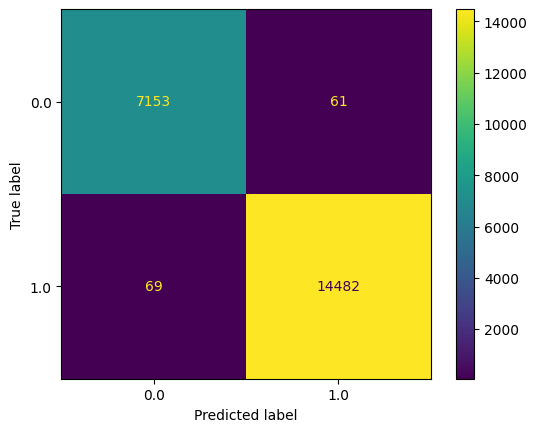

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_train, model.predict(X_train))

# Create the ConfusionMatrixDisplay object
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

# Plot the confusion matrix
disp.plot()
plt.show()

-Model is giving good and generalized results on training and test set.

###Visualising decision tree

In [ ]:
column_names = list(X.columns)
feature_names = column_names
print(feature_names)

['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'required_car_parking_space', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest', 'no_of_previous_cancellations', 'avg_price_per_room', 'no_of_special_requests', 'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3', 'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary', 'market_segment_type_Corporate', 'market_segment_type_Offline', 'market_segment_type_Online']


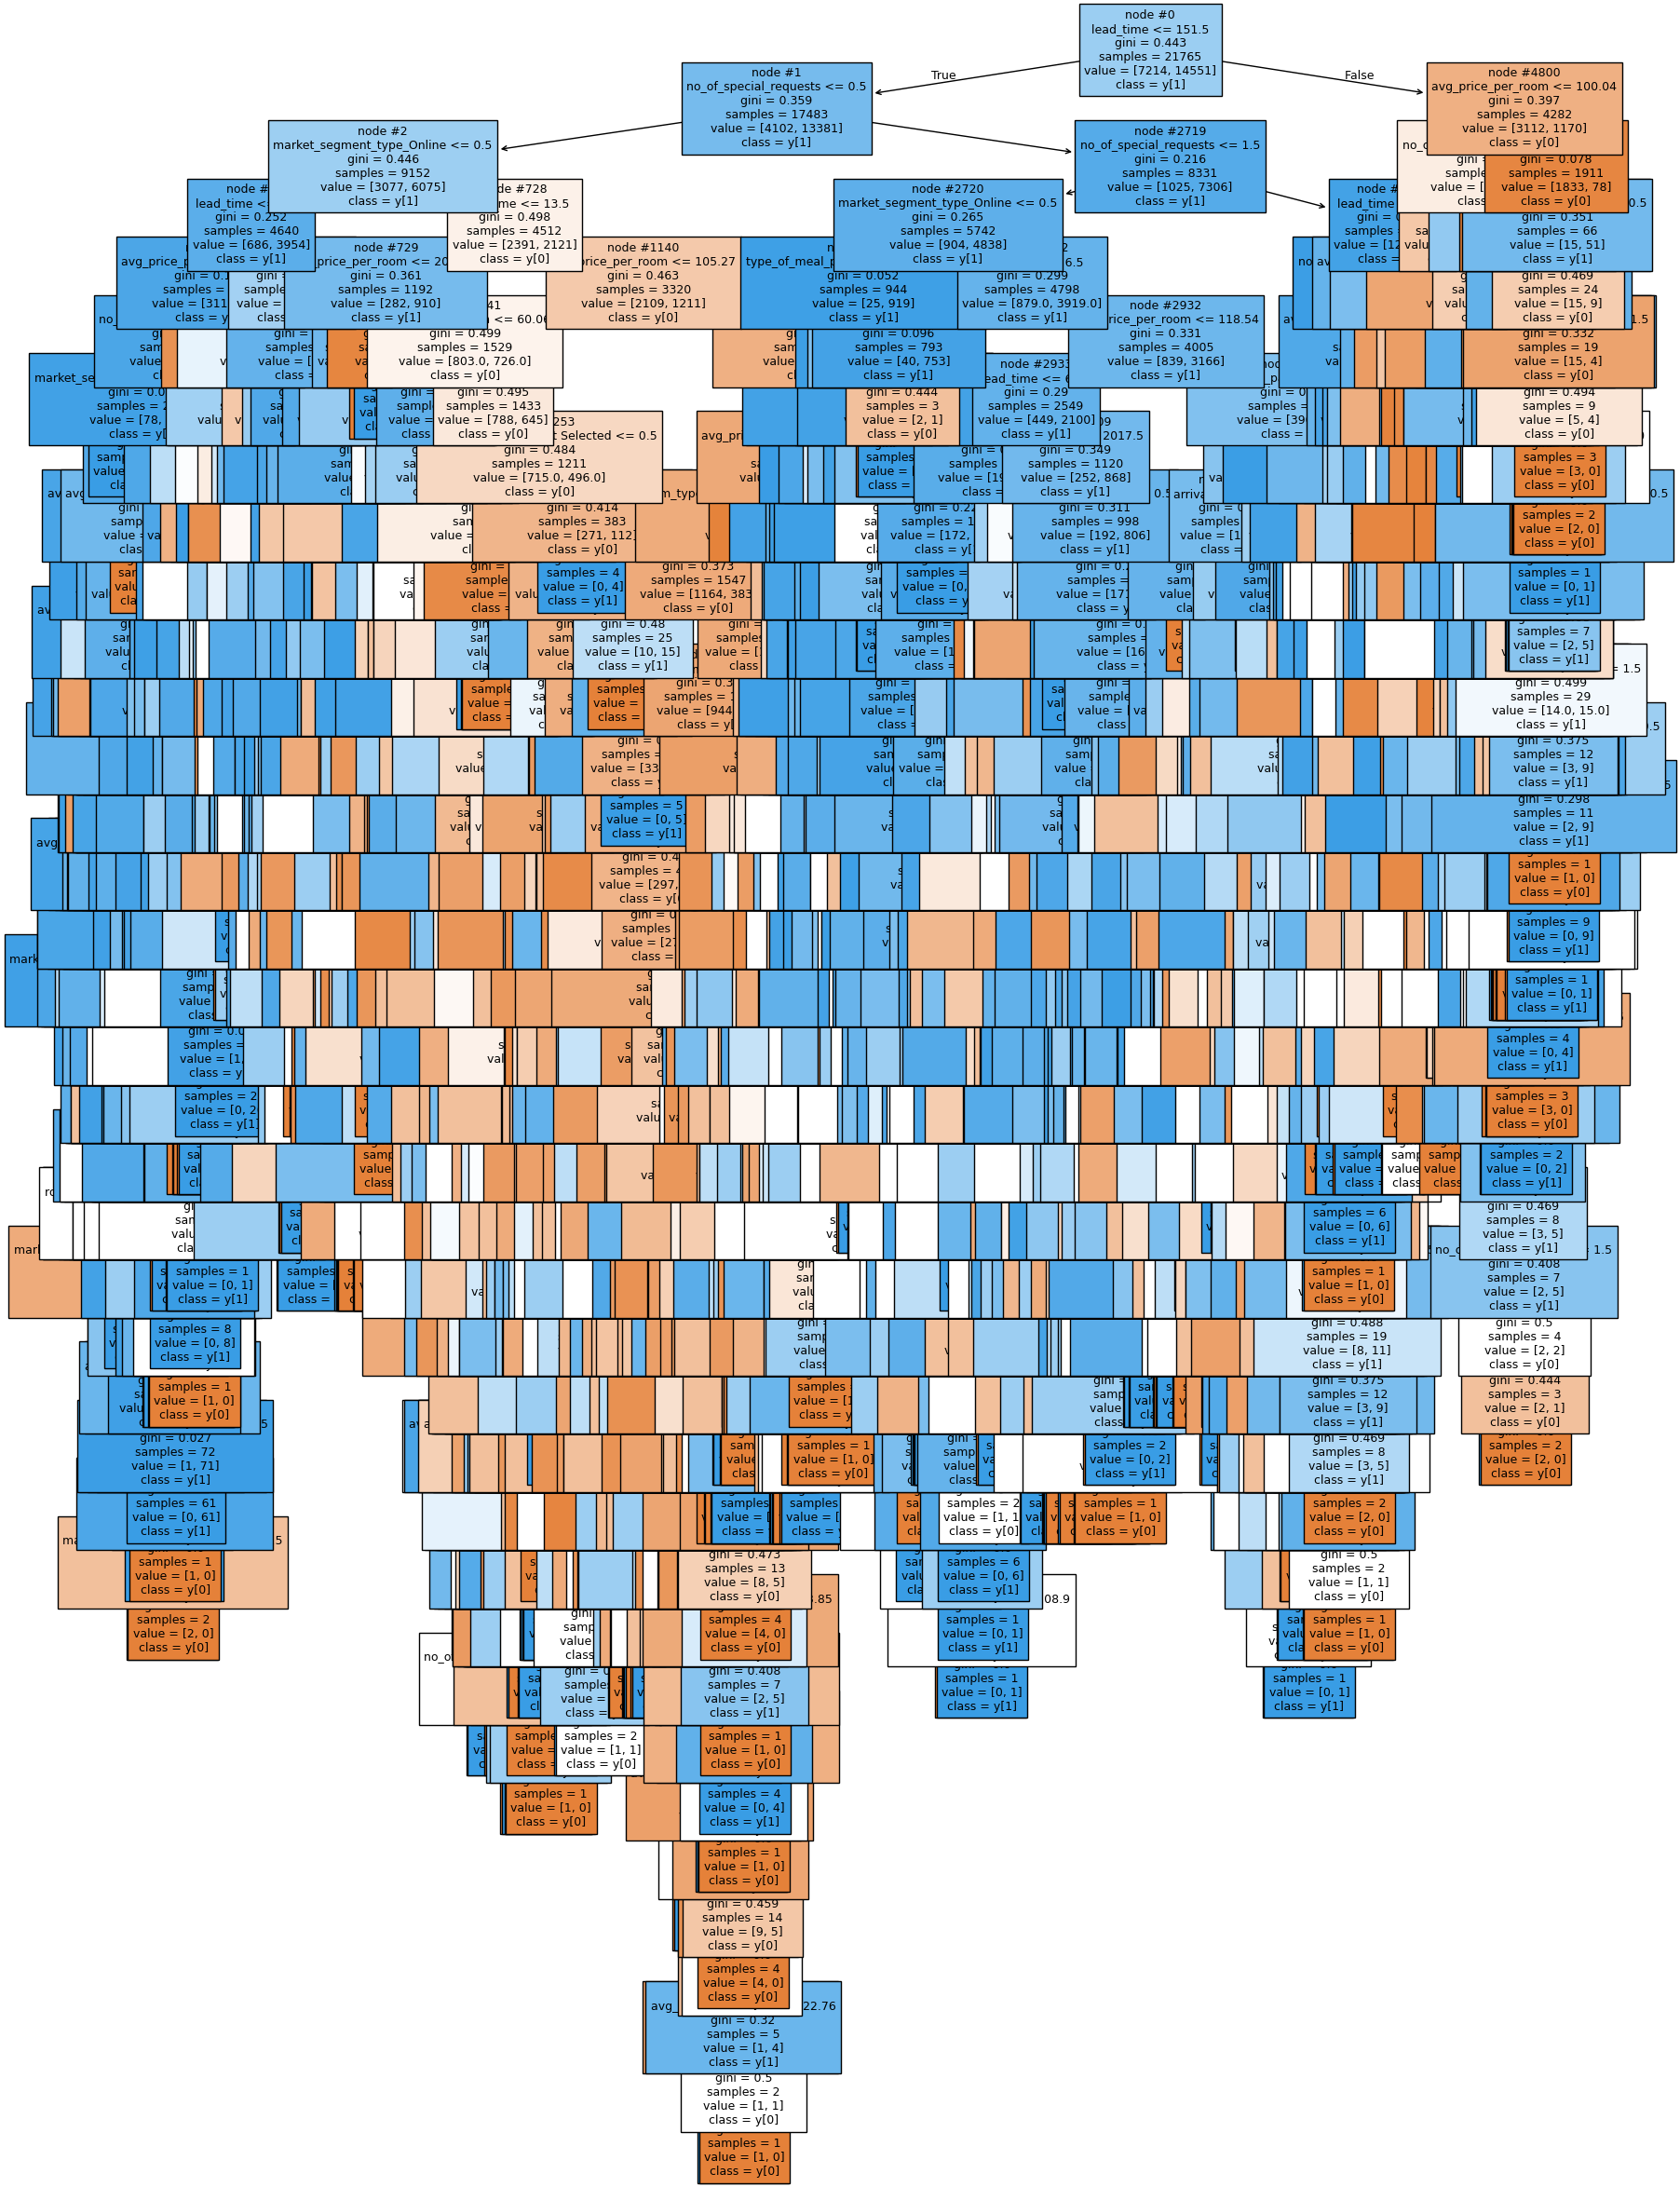

In [ ]:
plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(model, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- avg_price_per_room <= 201.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |--- lead_time <= 16.50
|   |   |   |   |   |   |   |   |--- avg_price_per_room <= 68.50
|   |   |   |   |   |   |   |   |   |--- repeated_guest <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- avg_price_per_room <= 48.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 54.00] class: 1.0
|   |   |   |   |   |   |   |   |   |   |--- avg_price_per_room >  48.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |   |   |   |   |   |--- repeated_guest >  0.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 89.00] class: 1.0
|   |   |   |   |   |   |   |   |--- avg_price_per_r

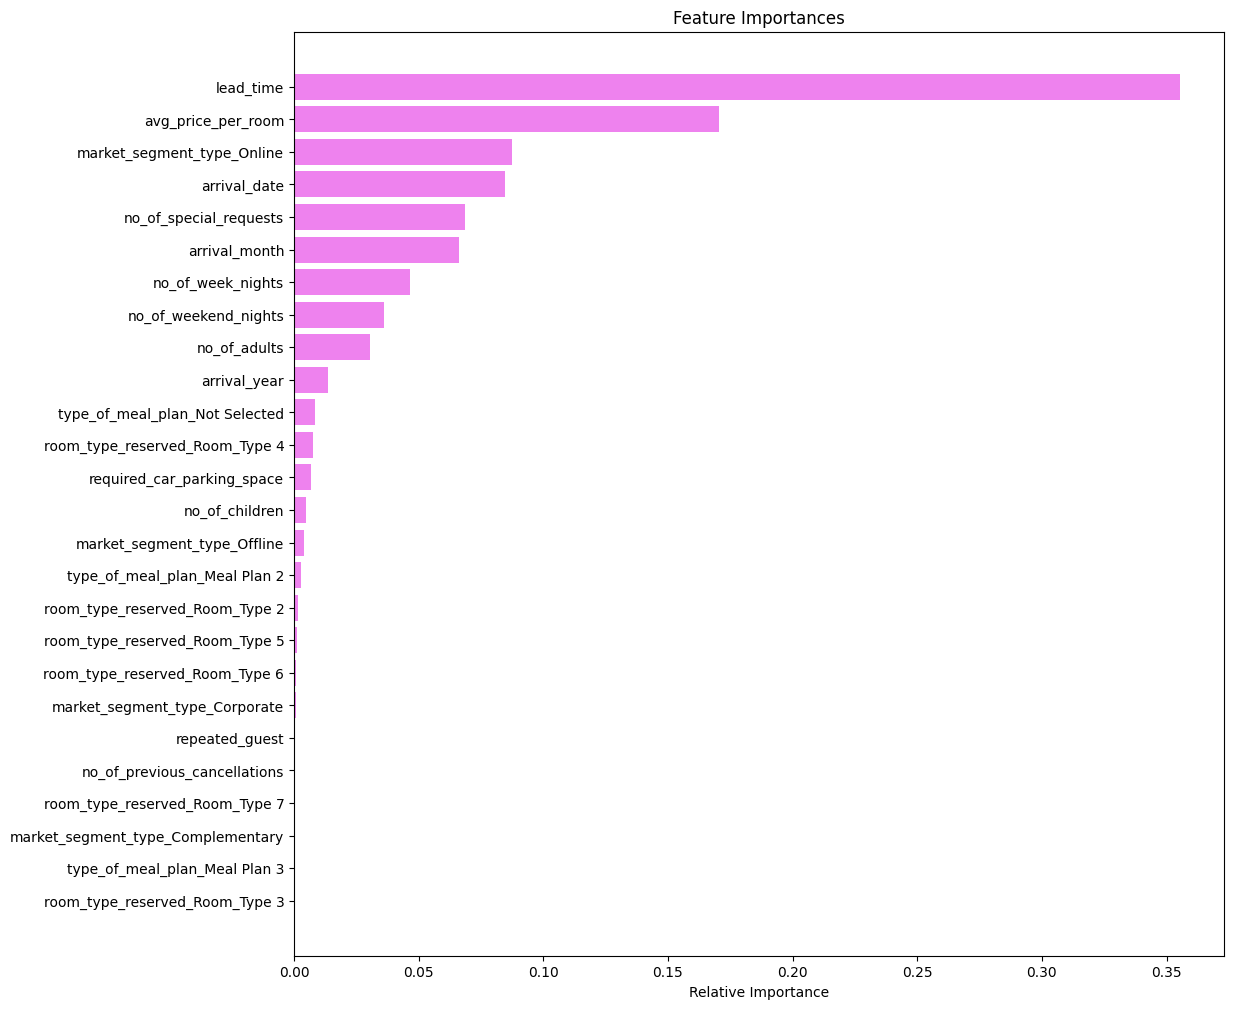

In [ ]:
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

The top 3 features are:
- Lead time
- Average price per room
- market segment type: online

## Do we need to prune the tree?

###Using GridSearch for Hyperparameter tuning of our tree mode

In [ ]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from

parameters = {
    "max_depth": [np.arange(2, 50, 5), None],
    "criterion": ["entropy", "gini"],
    "splitter": ["best", "random"],
    "min_impurity_decrease": [0.000001, 0.00001, 0.0001],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(min_impurity_decrease=0.0001, random_state=1)

###Checking performance on training set

In [ ]:
Decision_tree_tune_perf_train = model_performance_classification_sklearn(estimator, X_train, y_train
)
Decision_tree_tune_perf_train

{'Accuracy': 0.9057201929703652,
 'Precision': 0.9181106576570549,
 'Recall': 0.9430966943852657,
 'F1': 0.9304359617601193,
 'Confusion Matrix': array([[ 5990,  1224],
        [  828, 13723]])}

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def confusion_matrix_sklearn(estimator, X, y):
    """
    Plots the confusion matrix for a given estimator.

    Args:
        estimator: The fitted estimator.
        X: The input features.
        y: The target variable.
    """

    y_pred = estimator.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=estimator.classes_)
    disp.plot()
    plt.show()

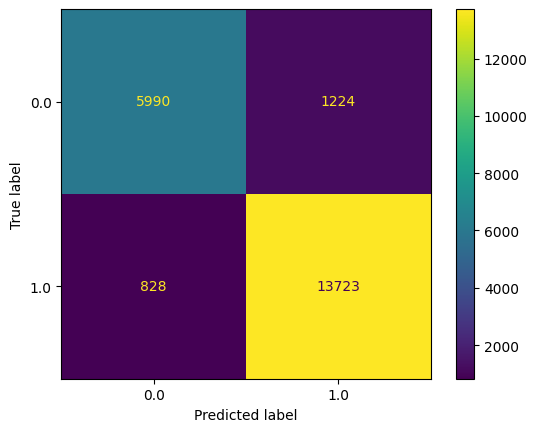

In [ ]:
confusion_matrix_sklearn(estimator, X_train, y_train)

###Checking the model performance on test set

In [ ]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(
    estimator, X_test, y_test
)

decision_tree_tune_perf_test

{'Accuracy': 0.8800137835975189,
 'Precision': 0.8990735265129115,
 'Recall': 0.9271267405224108,
 'F1': 0.9128846634976232,
 'Confusion Matrix': array([[3647, 1024],
        [ 717, 9122]])}

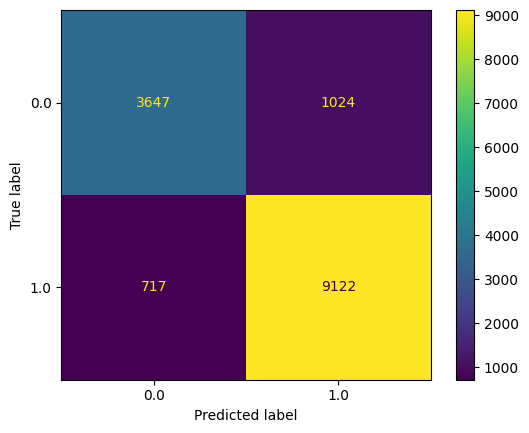

In [ ]:
confusion_matrix_sklearn(estimator, X_test, y_test)

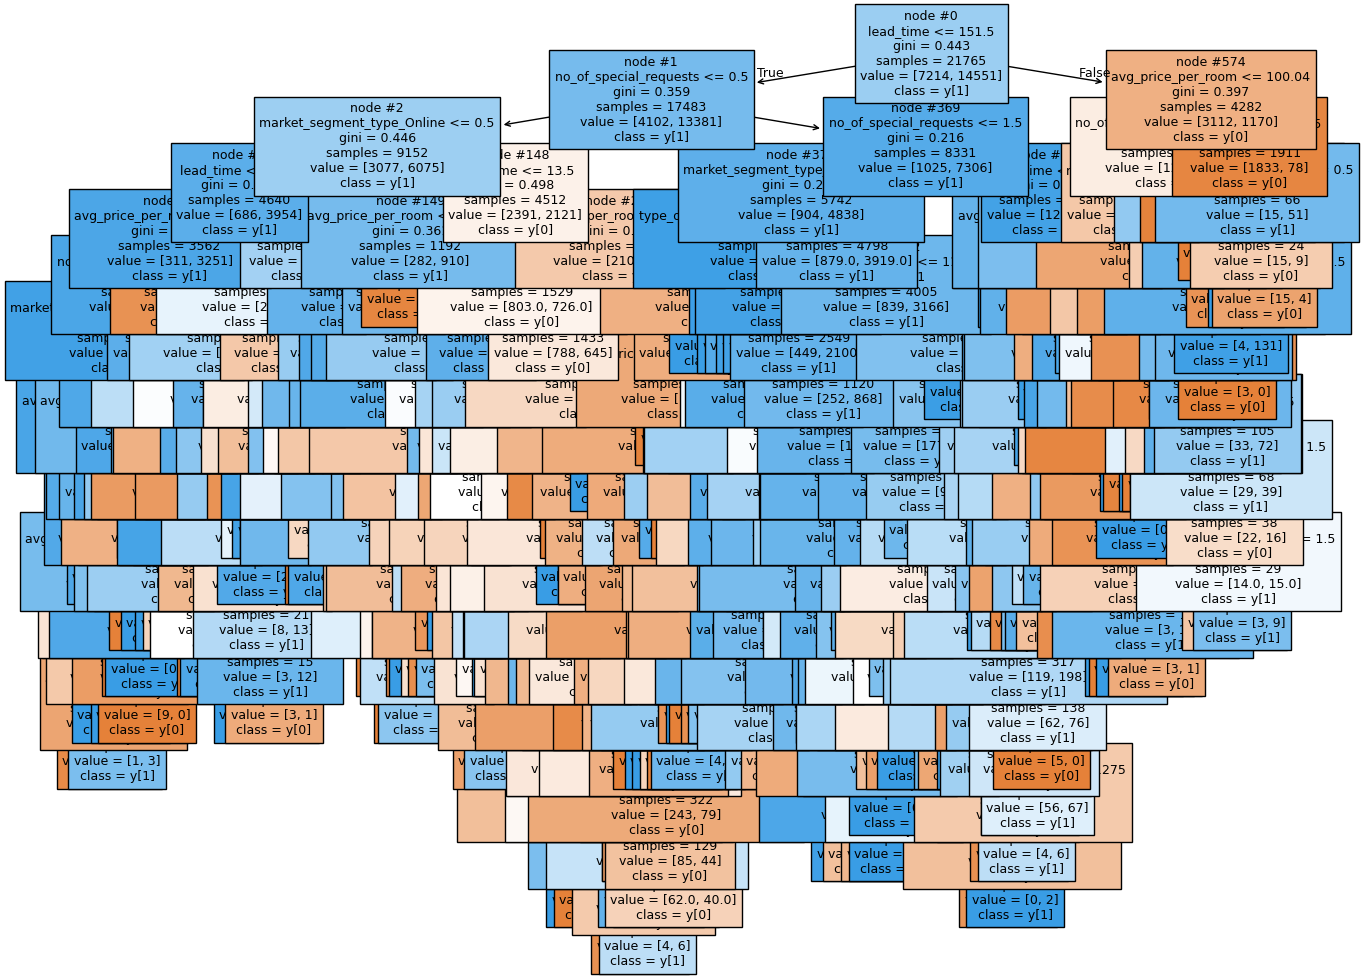

In [ ]:
plt.figure(figsize=(15, 12))

tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
plt.show()

- We are getting a simplified tree after pre-pruning.

###Cost Complexity Pruning

In [ ]:
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.00000,0.00755
1,0.00000,0.00755
2,0.00000,0.00755
3,0.00000,0.00755
4,0.00000,0.00756
...,...,...
1203,0.00646,0.28779
1204,0.01281,0.30060
1205,0.01713,0.31773
1206,0.02445,0.36663


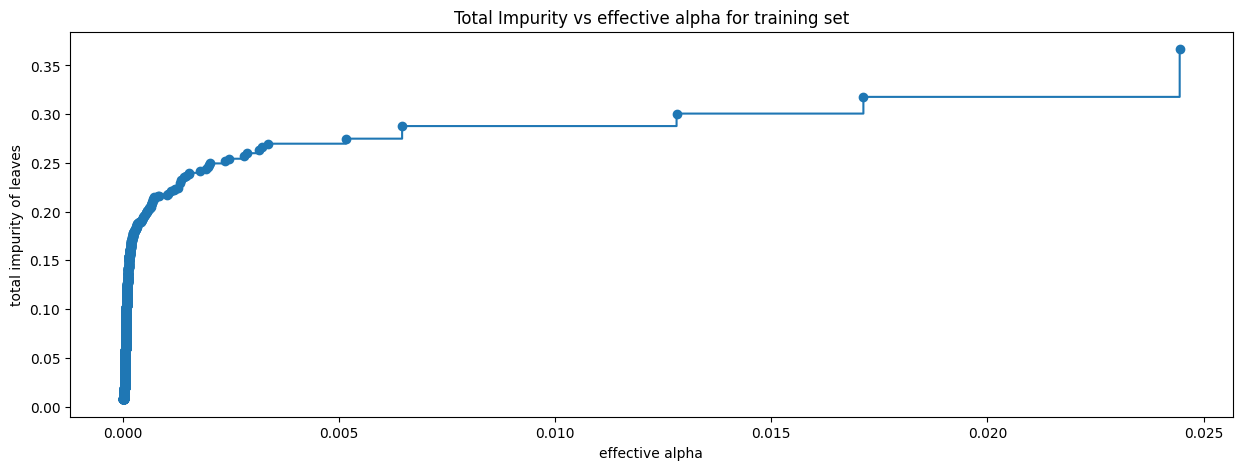

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.0765498344481233


###Recall vs alpha for training and testing sets

In [ ]:
recall_train = []
for clf in clfs:
    pred_train = clf.predict(X_train)
    values_train = recall_score(y_train, pred_train)
    recall_train.append(values_train)

In [ ]:
recall_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = recall_score(y_test, pred_test)
    recall_test.append(values_test)

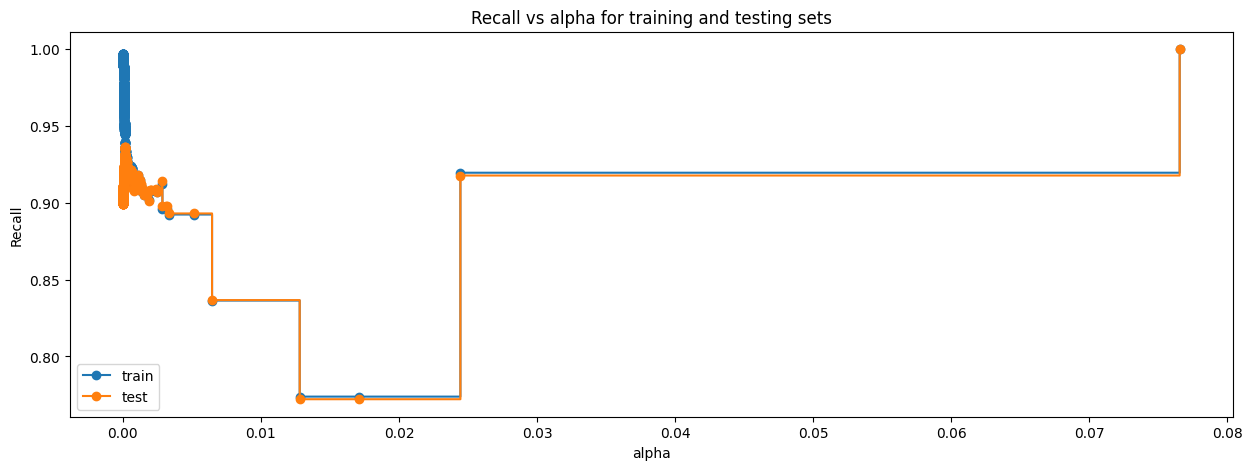

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=0.0765498344481233, random_state=1)


## Model Performance Comparison and Conclusions

###Checking model performance on training set

In [ ]:
decision_tree_postpruned_perf_train = model_performance_classification_sklearn(
    best_model, X_train, y_train
)
decision_tree_postpruned_perf_train

{'Accuracy': 0.6685504249942569,
 'Precision': 0.6685504249942569,
 'Recall': 1.0,
 'F1': 0.801354774754929,
 'Confusion Matrix': array([[    0,  7214],
        [    0, 14551]])}

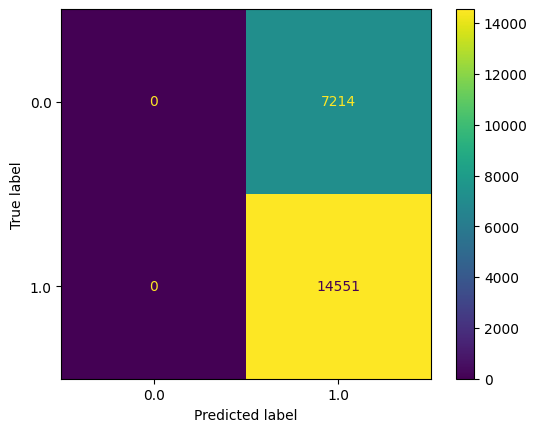

In [ ]:
confusion_matrix_sklearn(best_model, X_train, y_train)

### Checking model performance on test set

In [ ]:
decision_tree_postpruned_perf_test = model_performance_classification_sklearn(
    best_model, X_test, y_test
)
decision_tree_postpruned_perf_test

{'Accuracy': 0.6780840799448656,
 'Precision': 0.6780840799448656,
 'Recall': 1.0,
 'F1': 0.8081646063493367,
 'Confusion Matrix': array([[   0, 4671],
        [   0, 9839]])}

* With post-pruning we are getting good and generalized model performance on both training and test set.
* The recall has improved further.

###Visualizing the Decision Tree

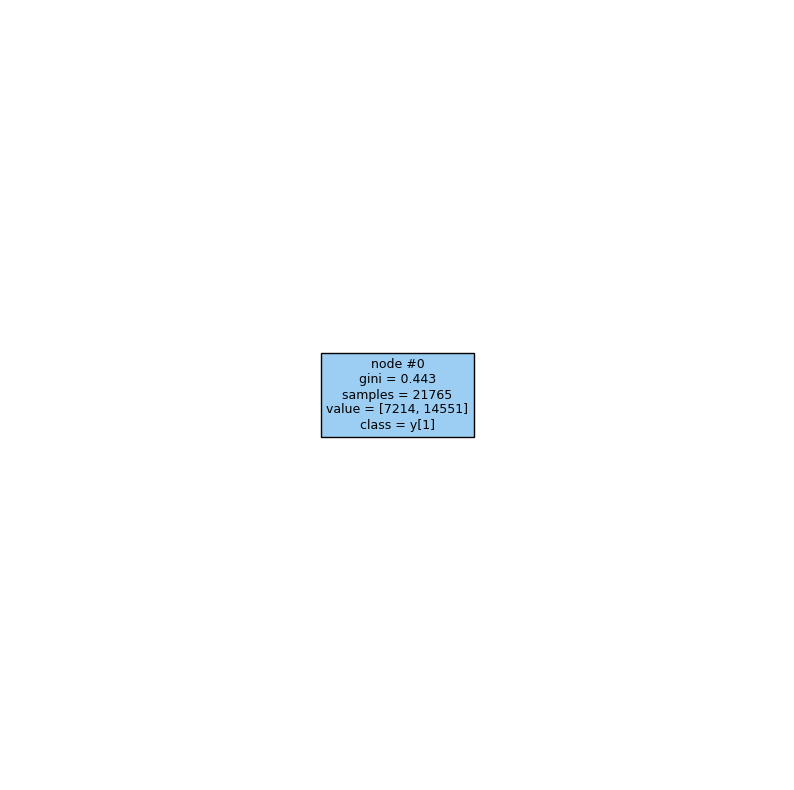

In [ ]:
plt.figure(figsize=(10, 10))

out = tree.plot_tree(
    best_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=True,
)
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()
plt.show()

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

|--- weights: [7214.00, 14551.00] class: 1.0



In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
# (normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print(
    pd.DataFrame(
        best_model.feature_importances_, columns=["Imp"], index=X_train.columns
    ).sort_values(by="Imp", ascending=False)
)

                                      Imp
no_of_adults                      0.00000
no_of_children                    0.00000
market_segment_type_Offline       0.00000
market_segment_type_Corporate     0.00000
market_segment_type_Complementary 0.00000
room_type_reserved_Room_Type 7    0.00000
room_type_reserved_Room_Type 6    0.00000
room_type_reserved_Room_Type 5    0.00000
room_type_reserved_Room_Type 4    0.00000
room_type_reserved_Room_Type 3    0.00000
room_type_reserved_Room_Type 2    0.00000
type_of_meal_plan_Not Selected    0.00000
type_of_meal_plan_Meal Plan 3     0.00000
type_of_meal_plan_Meal Plan 2     0.00000
no_of_special_requests            0.00000
avg_price_per_room                0.00000
no_of_previous_cancellations      0.00000
repeated_guest                    0.00000
arrival_date                      0.00000
arrival_month                     0.00000
arrival_year                      0.00000
lead_time                         0.00000
required_car_parking_space        

#Comparison of Models and Final Model Selection

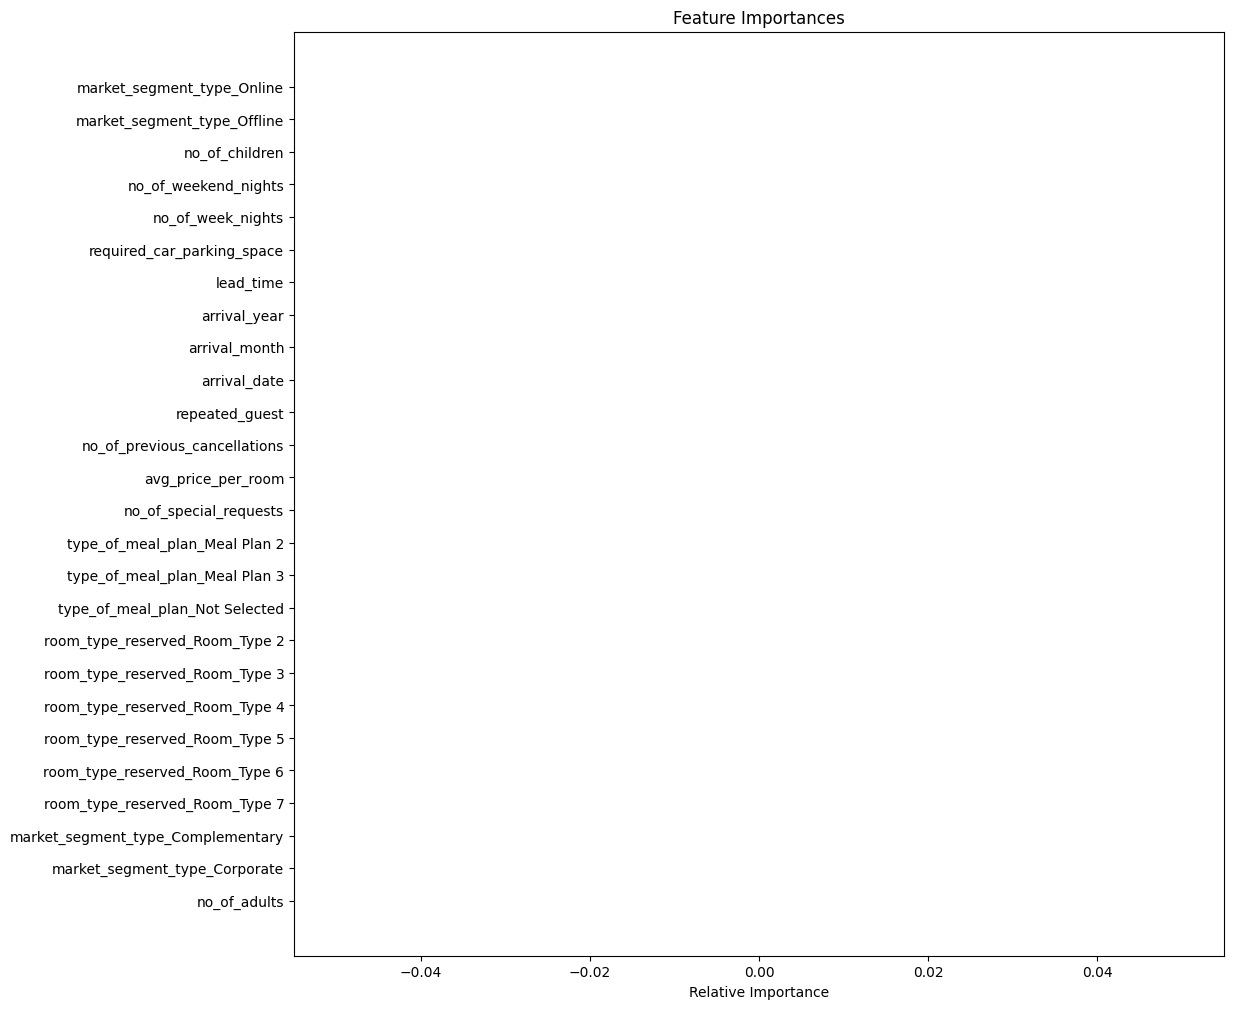

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]

# Fit the model before using it
best_model.fit(X_train, y_train)  # This line is crucial

importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()


In [ ]:
# Import necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Create basic decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Create decision tree with class weights
dt_weighted = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_weighted.fit(X_train, y_train)
dt_weighted_pred = dt_weighted.predict(X_test)

# Create decision tree with post-pruning (using ccp_alpha for example)
dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=0.01)
dt_pruned.fit(X_train, y_train)
dt_pruned_pred = dt_pruned.predict(X_test)

# Calculate performance metrics for each model
decision_tree_perf_test = pd.Series({
    'Accuracy': accuracy_score(y_test, dt_pred),
    'Precision': precision_score(y_test, dt_pred),
    'Recall': recall_score(y_test, dt_pred),
    'F1-score': f1_score(y_test, dt_pred)
})

decision_tree_tune_perf_test = pd.Series({
    'Accuracy': accuracy_score(y_test, dt_weighted_pred),
    'Precision': precision_score(y_test, dt_weighted_pred),
    'Recall': recall_score(y_test, dt_weighted_pred),
    'F1-score': f1_score(y_test, dt_weighted_pred)
})

decision_tree_post_test = pd.Series({
    'Accuracy': accuracy_score(y_test, dt_pruned_pred),
    'Precision': precision_score(y_test, dt_pruned_pred),
    'Recall': recall_score(y_test, dt_pruned_pred),
    'F1-score': f1_score(y_test, dt_pruned_pred)
})

# Combine the performance metrics
models_test_comp_df = pd.concat(
    [
        decision_tree_perf_test.T,
        decision_tree_tune_perf_test.T,
        decision_tree_post_test.T,
    ],
    axis=1,
)

models_test_comp_df.columns = [
    "Decision Tree without class_weight",
    "Decision Tree with class_weight",
    "Decision Tree (Post-Pruning)"
]

print("Test set performance comparison:")
print(models_test_comp_df)

Test set performance comparison:
           Decision Tree without class_weight  \
Accuracy                              0.86988   
Precision                             0.90687   
Recall                                0.90060   
F1-score                              0.90372   

           Decision Tree with class_weight  Decision Tree (Post-Pruning)  
Accuracy                           0.86340                       0.80041  
Precision                          0.90239                       0.86462  
Recall                             0.89542                       0.83667  
F1-score                           0.89889                       0.85041  


- The decision tree without class weight is the best model, with the heighest recall.

## Actionable Insights and Recommendations

** What profitable policies for cancellations and refunds can the hotel adopt?**
The longer the leadtime, the greater the chance of a cancellation. As the booking date approaches the refund can be scaled. Eg. Cancellation in two months before check-in date: 100% refund, within 1 month 50%, thereafter no refund. This ensure enough time to fill the canceled booking.

**What other recommedations would you suggest to the hotel? **
- The average price should be determined keeping in mind that as the price decreased, the cancellation rate will increase.
- Online has a lower cancellation rate than offline
- The hotel is busiest from October to March.Canellation policies should be more strict during these months.
- Guests with 3 or more requests who book online are less likely to , may be offered less strict cancellation policies.